In [1]:
import os
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy import interpolate
from scipy.signal import savgol_filter
from scipy.io import loadmat
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Functions I am adding
import modin.pandas as mpd
import ray
import scipy.signal as signal
import statsmodels.api as sm
import umap

from scipy.stats import skew, kurtosis, entropy
from scipy.fft import fft
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller

ray.init(ignore_reinit_error=True, num_cpus=os.cpu_count()-1)

2025-11-01 14:50:28,636	INFO worker.py:1718 -- Calling ray.init() again after it has already been called.


Python version:,3.11.11
Ray version:,2.46.0


# Read raw data

In [3]:
# Load label names    
label_names = loadmat('label_names.mat', squeeze_me=True)
activity_names_indexed = label_names['activity_names_indexed']

In [4]:
# Set constant variables
SAMPLE_RATE = 32
WINDOW_SIZE = 4 * 128
TIME_EXCLUDE = 2
CHUNK = 128
my_netid = "lol404"

# Loading and Processing Helper Functions
def load_label_info():
    """Load label names and create mapping from name→number."""
    label_data = loadmat("label_names.mat", squeeze_me=True)
    activity_names = label_data["activity_names_indexed"]
    mapping = {name: idx for idx, name in enumerate(activity_names, start=1)}
    return activity_names, mapping

def parse_filename(file_name, dir_name):
    """Extract user ID, file prefix, and activity name from filename."""
    substr = dir_name[dir_name.find("allData/") + 8:]
    prefix_cut = 11 + len(substr)
    if file_name.startswith("null"):
        activity_name = file_name[25:-prefix_cut]
    else:
        activity_name = file_name[36:-prefix_cut]
    file_common = file_name[:-(10)]
    return substr, file_common, activity_name

def load_accel_data(file_path):
    """Load and clean accelerometer data."""
    data = np.loadtxt(file_path, delimiter=",")
    ts = data[:, 0]
    dup_idx = np.where(ts[:-1] == ts[1:])[0]
    data = np.delete(data, dup_idx, axis=0)
    df = pd.DataFrame(data, columns=["ts", "accel_x", "accel_y", "accel_z"])
    df = df.sort_values("ts").interpolate(method="spline", order=2)
    return df

def load_baro_data(file_path, target_len):
    """Load, deduplicate, interpolate, and smooth barometer data."""
    bar_data = np.loadtxt(file_path, delimiter=",")
    ts_bar = bar_data[:, 0]
    dup_idx = np.where(ts_bar[:-1] == ts_bar[1:])[0]
    bar_data = np.delete(bar_data, dup_idx, axis=0)
    interp_idx = np.linspace(0, len(bar_data) - 1, target_len)
    interp_func = interp1d(np.arange(len(bar_data)), bar_data[:, 1],
                           kind="linear", fill_value="extrapolate")
    y_bar = interp_func(interp_idx)
    y_bar_smoothed = savgol_filter(y_bar, WINDOW_SIZE, 1, mode="nearest")
    return y_bar_smoothed

def trim_data(df, y_bar):
    """Trim first/last few seconds from both accel and barometer."""
    start = int(TIME_EXCLUDE * SAMPLE_RATE)
    end = -start if start > 0 else None
    df_trim = df.iloc[start:end]
    y_bar_trim = y_bar[start:end]
    return df_trim, y_bar_trim

def prepare_fixed_blocks(df_accel, y_bar, activity, user, label):
    """Ensure dataset is multiple of CHUNK=128 samples."""
    usable_len = CHUNK * (len(y_bar) // CHUNK)
    if usable_len <= 0:
        return pd.DataFrame()
    df_accel = df_accel.iloc[:usable_len].copy()
    df_accel["y_bar"] = y_bar[:usable_len]
    df_accel["activity"] = activity
    df_accel["user"] = user
    df_accel["label"] = label
    return df_accel

# Parallel Worker
@ray.remote
def process_file(file_name, dir_name, activity_names, mapping):
    """Process one accel file (and its matching pressure file)."""
    substr, file_common, activity_name = parse_filename(file_name, dir_name)
    if activity_name not in activity_names:
        return pd.DataFrame()
    accel_path = os.path.join(dir_name, file_name)
    baro_path = os.path.join(dir_name, file_common + "-pressure.txt")
    df_accel = load_accel_data(accel_path)
    y_bar = load_baro_data(baro_path, len(df_accel))
    df_accel, y_bar = trim_data(df_accel, y_bar)
    df_out = prepare_fixed_blocks(df_accel, y_bar,
                                  activity_name, substr, mapping[activity_name])
    return df_out

# Main per-user computation
def compute_raw_data_parallel(dir_name):
    """Parallelized raw data extraction for a single user directory."""
    activity_names, mapping = load_label_info()
    files = [f for f in os.listdir(dir_name) if f.endswith("-accel.txt")]
    tasks = [process_file.remote(f, dir_name, activity_names, mapping) for f in files]
    results = ray.get(tasks)
    if not results:
        return pd.DataFrame()
    return pd.concat(results, ignore_index=True)

# Iterate over all user directories
def build_full_dataset(base_dir):
    """Iterate over all user directories under 'allData/' and combine results."""
    col_names = ['ts', 'accel_x', 'accel_y', 'accel_z', 'y_bar', 'label', 'user', 'activity']
    df_raw = pd.DataFrame(columns=col_names)

    for data_dir_name in os.listdir(base_dir):
        user_path = os.path.join(base_dir, data_dir_name)
        if os.path.isdir(user_path) and not data_dir_name.startswith("."):
            print(f"Processing directory: {data_dir_name}")
            df_temp = compute_raw_data_parallel(user_path)

            # Only sort/append if non-empty and contains expected columns
            if not df_temp.empty and all(col in df_temp.columns for col in ['label', 'ts']):
                df_temp = df_temp.sort_values(by=['label', 'ts'], ignore_index=True)
                df_raw = pd.concat([df_raw, df_temp], ignore_index=True)
            else:
                print(f"⚠️ Skipping {data_dir_name}: no valid data found")

    return df_raw

# Main Pipeline
def compute_raw_data_parallel(dir_name):
    """Parallelized and modularized raw data extraction pipeline."""
    activity_names, mapping = load_label_info()
    files = [f for f in os.listdir(dir_name) if f.endswith("-accel.txt")]

    tasks = [
        process_file.remote(f, dir_name, activity_names, mapping)
        for f in files
    ]
    results = ray.get(tasks)
    return pd.concat(results, ignore_index=True)

In [9]:
# Run the full pipeline
data_dir = os.path.join(os.getcwd(), "allData")
df_raw = build_full_dataset(data_dir)

# Keep only the desired columns (and ensure order)
col_names_raw = ['ts', 'accel_x', 'accel_y', 'accel_z', 'y_bar', 'label', 'user', 'activity']
df_raw = df_raw[[col for col in col_names_raw if col in df_raw.columns]]

print(f"Final dataset shape: {df_raw.shape}")
df_raw

Processing directory: vbagdi
Processing directory: ahs264
Processing directory: cyt25
⚠️ Skipping cyt25: no valid data found
Processing directory: xl549
Processing directory: jl2855
Processing directory: xz278
Processing directory: johnsweeney
⚠️ Skipping johnsweeney: no valid data found
Processing directory: Grack
Processing directory: mmill
Processing directory: mrossman
Processing directory: cstewie
Processing directory: sutreja
Processing directory: s1n1
Processing directory: yinuoinno
Processing directory: jao57
⚠️ Skipping jao57: no valid data found
Processing directory: jude
Processing directory: aaleksanyan
Processing directory: yaw006
Processing directory: aks249
Processing directory: mmb289
Processing directory: av452
Processing directory: sp2333
Processing directory: nbw32
Processing directory: nk428
Processing directory: mlc299
Processing directory: cgp46
Processing directory: wh298
Processing directory: s3chowdhury
Processing directory: jps394
Processing directory: shrek16

,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity
0,1.761522e+12,-0.443601,-0.537366,9.946635,1001.999464,1,vbagdi,Stationary
1,1.761522e+12,-0.381671,-0.494507,10.008340,1001.999263,1,vbagdi,Stationary
2,1.761522e+12,-0.415024,-0.532604,9.908663,1001.999056,1,vbagdi,Stationary
3,1.761522e+12,-0.395971,-0.513556,9.908663,1001.998843,1,vbagdi,Stationary
4,1.761522e+12,-0.386446,-0.513557,9.918155,1001.998624,1,vbagdi,Stationary
...,...,...,...,...,...,...,...,...
7091067,1.760986e+12,2.644069,-0.965504,7.988439,1004.050420,7,xichen,Elevator-down
7091068,1.760986e+12,2.654238,-0.922433,7.983055,1004.051759,7,xichen,Elevator-down
7091069,1.760986e+12,2.673979,-0.869791,8.021339,1004.053094,7,xichen,Elevator-down
7091070,1.760986e+12,2.674577,-0.816551,8.044670,1004.054423,7,xichen,Elevator-down


# Visualize raw data

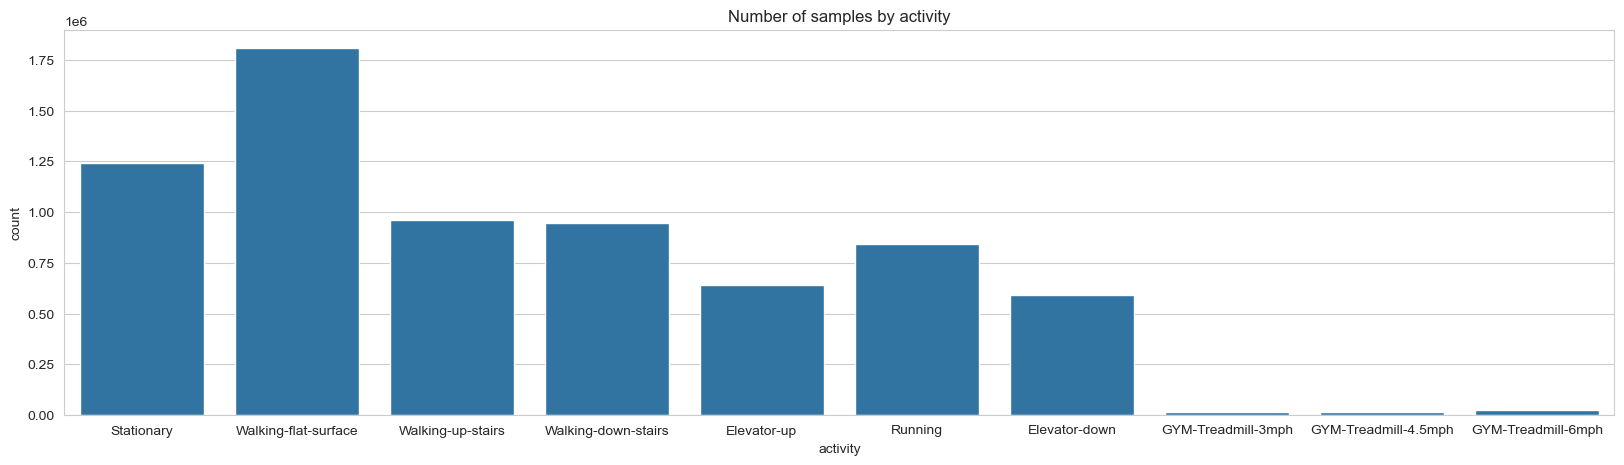

In [10]:
# Distribution of activities 
sns.set_style("whitegrid")
plt.figure(figsize = (20, 5))
sns.countplot(x = "activity", data = df_raw)
plt.title("Number of samples by activity")
plt.show()

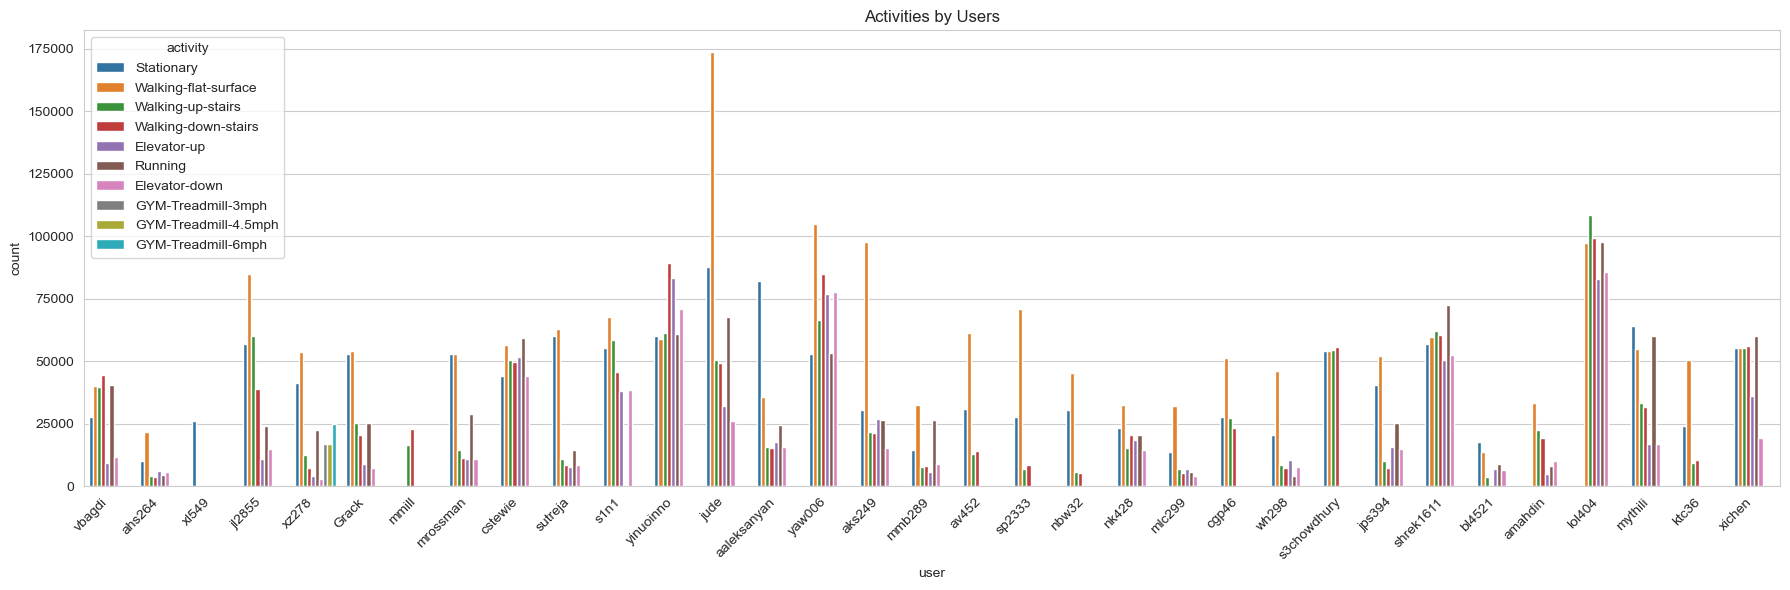

In [12]:
# Distribution of activities among different users
plt.figure(figsize=(18, 6))
sns.countplot(x="user", hue="activity", data=df_raw)
plt.title("Activities by Users")
plt.xticks(rotation=45, ha='right')  # 🔹 rotate labels and align right
plt.tight_layout()  # 🔹 adjust spacing to prevent cutoff
plt.show()

In [13]:
# splitting train data and test data 
df_train = df_raw[df_raw['user'] != my_netid]
df_test = df_raw[df_raw['user'] == my_netid]

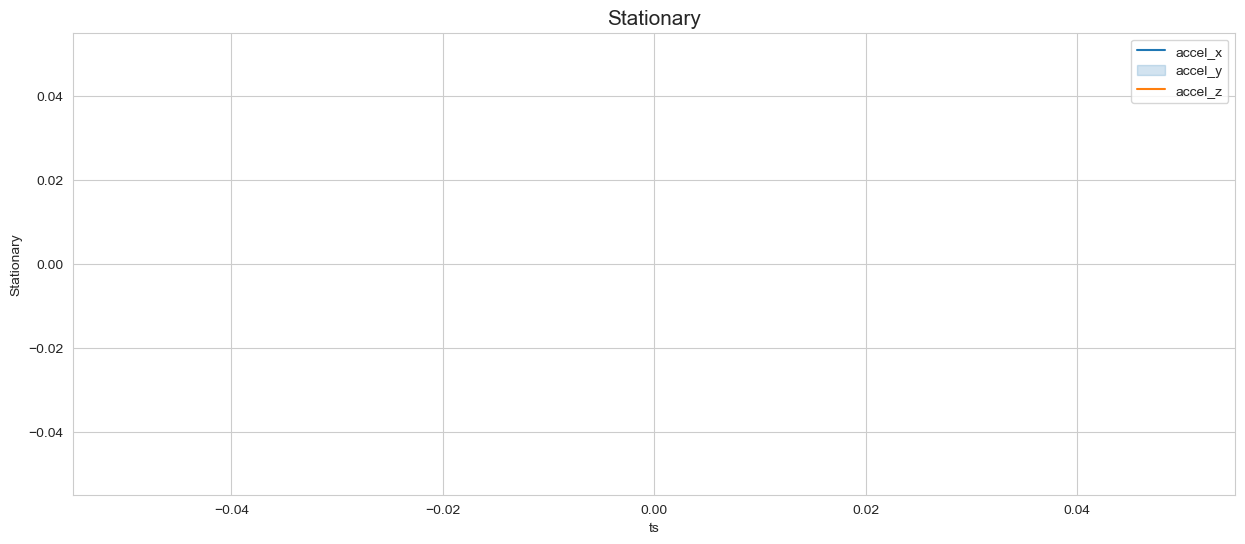

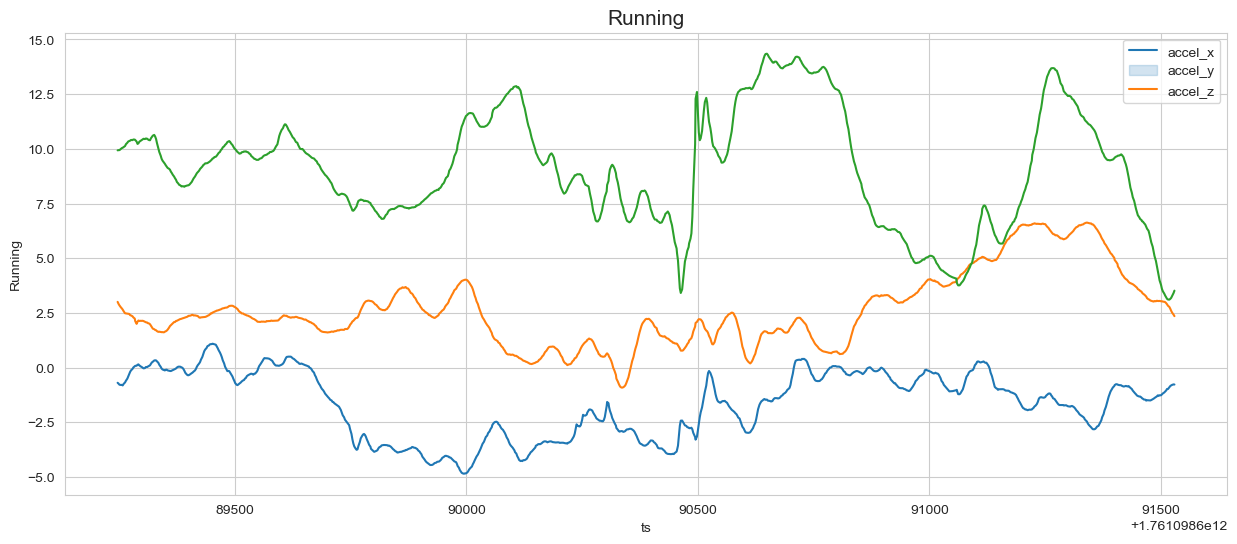

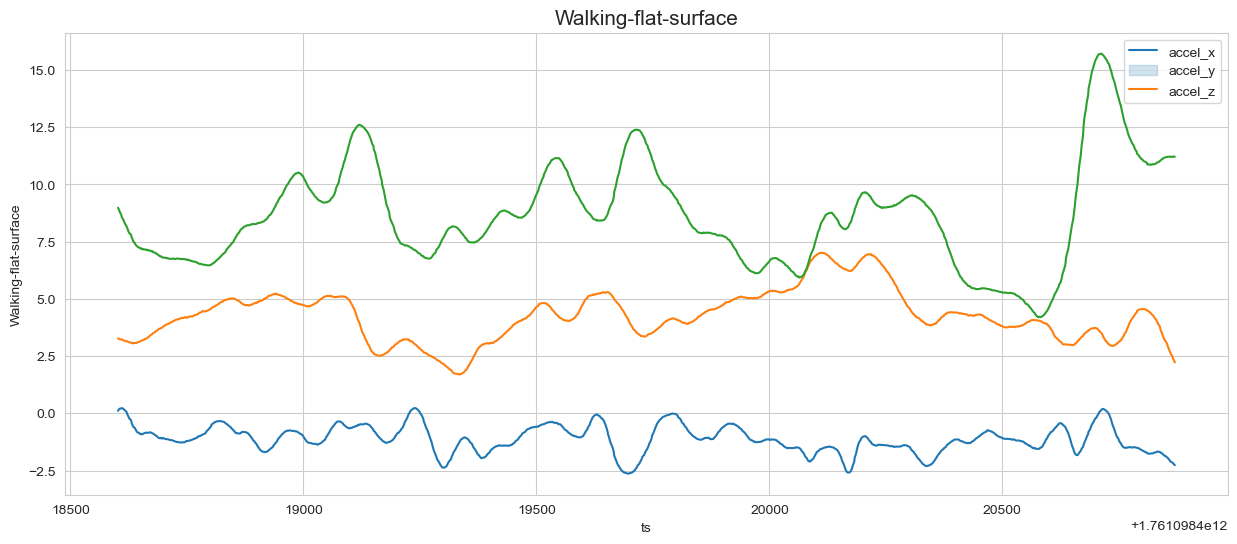

In [14]:
# Visual representation of raw data
# Note how the magnitudes and signal varies for each activity

for i in ["Stationary", "Running", "Walking-flat-surface"]:
    data_x = df_raw[(df_raw["user"] == my_netid) & (df_raw["activity"] == i)][:1000]
    plt.figure(figsize = (15, 6))
    sns.lineplot(y = "accel_x", x = "ts", data = data_x)
    sns.lineplot(y = "accel_y", x = "ts", data = data_x)
    sns.lineplot(y = "accel_z", x = "ts", data = data_x)
    plt.legend(["accel_x", "accel_y", "accel_z"])
    plt.ylabel(i)
    plt.title(i, fontsize = 15)
    plt.show()

# Check ARMA assumptions

## Stationarity

In [ ]:
def plot_user_activity(df, user_id=None, activity_name="Walking-flat-surface", random=True):
    """
    Plot accel_x, accel_y, accel_z, and barometric pressure for a given user and activity.
    If random=True, picks a random user who performed that activity.
    
    Parameters:
        df (pd.DataFrame): The full dataset (df_raw)
        user_id (str): Specific user ID (ignored if random=True)
        activity_name (str): Activity name (e.g. 'Walking-flat-surface')
        random (bool): Whether to pick a random user instead of specifying one
    """
    # Pick random user if requested
    if random:
        users = df[df["activity"] == activity_name]["user"].unique()
        user_id = np.random.choice(users)
        print(f"Randomly selected user: {user_id}")

    # Filter
    df_user = df[(df["user"] == user_id) & (df["activity"] == activity_name)]

    # Extract signals
    accel_x = df_user["accel_x"].dropna().reset_index(drop=True)
    accel_y = df_user["accel_y"].dropna().reset_index(drop=True)
    accel_z = df_user["accel_z"].dropna().reset_index(drop=True)
    baro = df_user["y_bar"].dropna().reset_index(drop=True)

    # Plot
    fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(accel_x, color='tab:blue')
    axes[0].set_title(f"Accel_x for {user_id} ({activity_name})")
    axes[0].set_ylabel("Accel X")

    axes[1].plot(accel_y, color='tab:orange')
    axes[1].set_title("Accel_y")
    axes[1].set_ylabel("Accel Y")

    axes[2].plot(accel_z, color='tab:green')
    axes[2].set_title("Accel_z")
    axes[2].set_ylabel("Accel Z")

    axes[3].plot(baro, color='tab:red')
    axes[3].set_title("Barometric Pressure")
    axes[3].set_xlabel("Time index")
    axes[3].set_ylabel("Pressure")

    plt.tight_layout()
    plt.show()

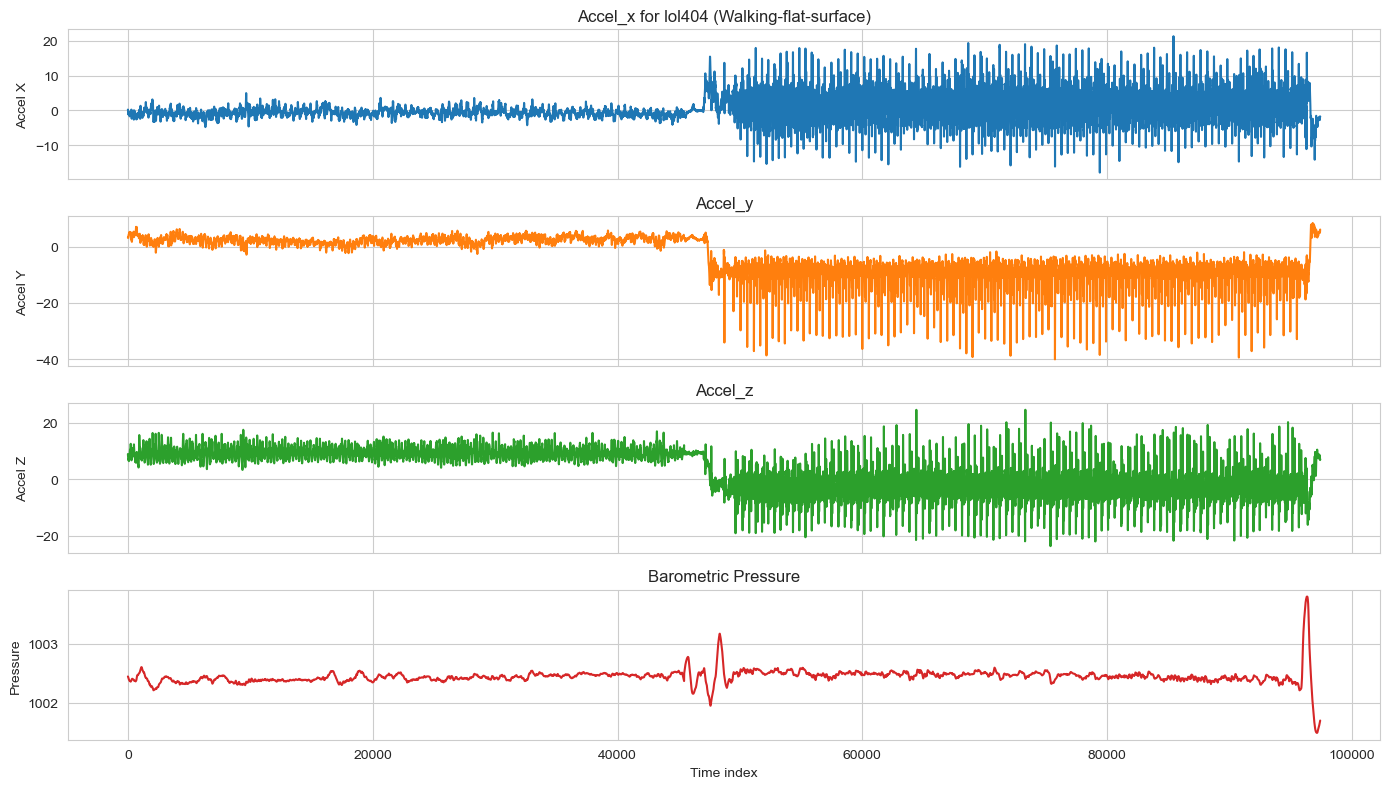

In [100]:
activity_walk = "Walking-flat-surface"
plot_user_activity(df_raw, my_netid, activity_walk, random = False)

🎲 Randomly selected user: cgp46


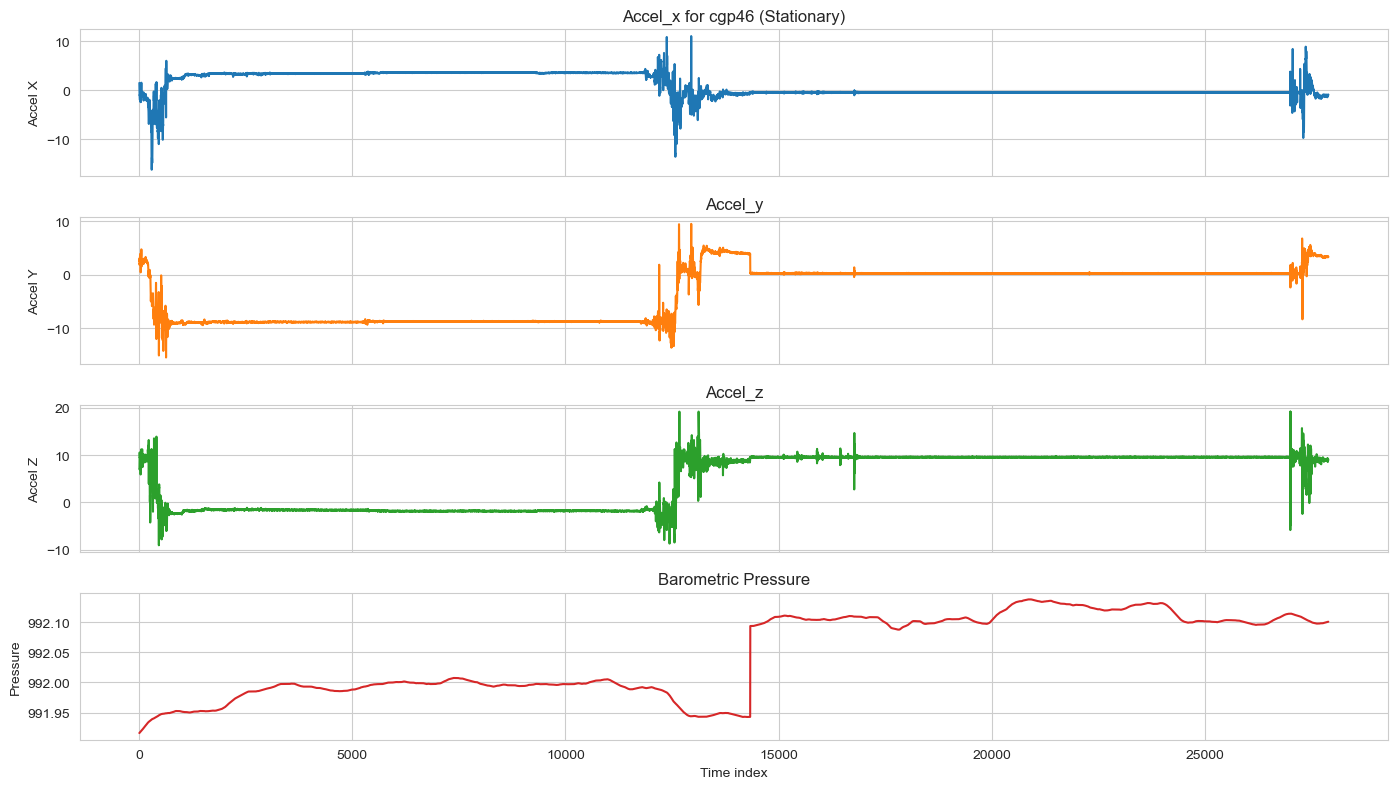

In [ ]:
plot_user_activity(df_raw, activity_walk, random=True)

🎲 Randomly selected user: ahs264


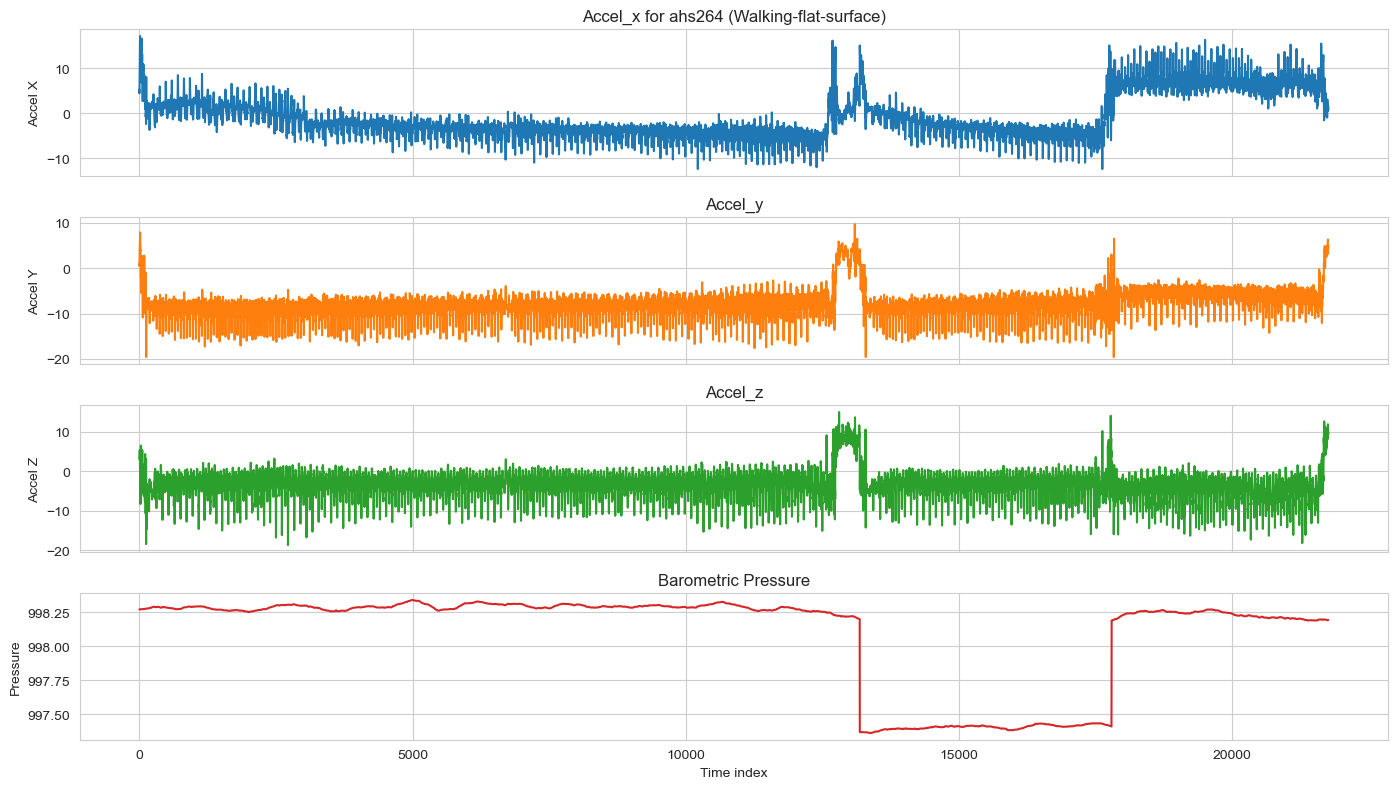

In [ ]:
plot_user_activity(df_raw, activity_walk, random=True)


In [142]:
# ------------------------------------------------------------
# 1️⃣ Helper — Robust session splitter by timestamp gaps
# ------------------------------------------------------------
def split_sessions(df, activity_name="Walking-flat-surface",
                   user_id=None, random=True,
                   gap_multiplier=5, min_gap_seconds=1.0, sample_rate=32):
    """Split user data into continuous sessions robustly against jitter."""
    # pick user
    if random or (user_id is None):
        users = df[df["activity"] == activity_name]["user"].unique()
        user_id = np.random.choice(users)
        print(f"🎲 Randomly selected user: {user_id}")
    else:
        print(f"👤 Using specified user: {user_id}")

    d = (df[(df["user"] == user_id) & (df["activity"] == activity_name)]
           .copy()
           .sort_values("ts")
           .reset_index(drop=True))

    if d.empty:
        print("⚠️ No data found for this user/activity.")
        return [], user_id

    ts = np.round(d["ts"].astype(float), 6)
    dt = np.diff(ts)
    dt_pos = dt[dt > 0]

    if len(dt_pos) == 0:
        print("✅ Continuous recording — single session detected.")
        return [d], user_id

    base_dt = np.median(dt_pos)
    min_gap = min_gap_seconds * sample_rate * base_dt
    gap_thr = max(gap_multiplier * base_dt, min_gap)
    cut_idx = np.where(dt > gap_thr)[0]

    starts = np.r_[0, cut_idx + 1]
    ends = np.r_[cut_idx + 1, len(d)]
    sessions = [d.iloc[s:e].reset_index(drop=True) for s, e in zip(starts, ends)]

    print(f"✂️ Found {len(sessions)} sessions for {user_id}")
    for i, s in enumerate(sessions, 1):
        dur = len(s) / sample_rate
        print(f"   Session {i}: {len(s)} samples (~{dur:.1f}s)")

    return sessions, user_id


# ------------------------------------------------------------
# 2️⃣ Helper — Truncate to shortest length + compute mean
# ------------------------------------------------------------
def truncate_and_mean_sessions(sessions, sensors, sample_rate=32):
    """Truncate all sessions to shortest length and compute per-sensor mean."""
    if not sessions:
        print("⚠️ No sessions to process.")
        return None

    min_len = min(len(s) for s in sessions)
    sessions = [s.iloc[:min_len] for s in sessions]

    mean_df = pd.DataFrame({
        sig: np.mean([s[sig].values[:min_len] for s in sessions], axis=0)
        for sig in sensors
    })
    mean_df["t"] = np.arange(min_len) / sample_rate
    return mean_df, sessions, min_len


# ------------------------------------------------------------
# 3️⃣ Helper — Plot each sensor's sessions and mean separately
# ------------------------------------------------------------
def plot_sessions_and_mean_by_sensor(sessions, mean_df, sensors, user_id, sample_rate=32):
    """Plot each sensor separately with its sessions and mean (stacked by sensor)."""
    for sig in sensors:
        min_len = len(mean_df)
        t = np.arange(min_len) / sample_rate

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                                       gridspec_kw={'height_ratios': [2, 1]})
        # Plot individual sessions
        for j, s in enumerate(sessions):
            ax1.plot(t, s[sig].values[:min_len], alpha=0.6, label=f"Session {j+1}")
        ax1.set_title(f"{sig.upper()} – Sessions ({user_id})")
        ax1.set_ylabel("Amplitude")
        ax1.legend(loc="upper right")

        # Plot mean signal
        ax2.plot(t, mean_df[sig], color="black", lw=2.5)
        ax2.set_title(f"{sig.upper()} – Mean Across Sessions")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Mean")

        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# 4️⃣ Main Wrapper — Everything in one call
# ------------------------------------------------------------
def plot_user_sessions_and_mean(df, activity_name="Walking-flat-surface",
                                user_id=None, random=True,
                                gap_multiplier=5, min_gap_seconds=1.0,
                                sample_rate=32,
                                sensors=["accel_x", "accel_y", "accel_z", "y_bar"]):
    """
    Full pipeline:
    1. Split sessions (robust to gaps)
    2. Truncate to shortest
    3. Compute mean
    4. Plot per-sensor: sessions + mean
    """
    sessions, user_id = split_sessions(df, activity_name, user_id, random,
                                       gap_multiplier, min_gap_seconds, sample_rate)
    mean_df, sessions, _ = truncate_and_mean_sessions(sessions, sensors, sample_rate)
    if mean_df is not None:
        plot_sessions_and_mean_by_sensor(sessions, mean_df, sensors, user_id, sample_rate)
    return mean_df

👤 Using specified user: lol404
✂️ Found 2 sessions for lol404
   Session 1: 45440 samples (~1420.0s)
   Session 2: 51968 samples (~1624.0s)


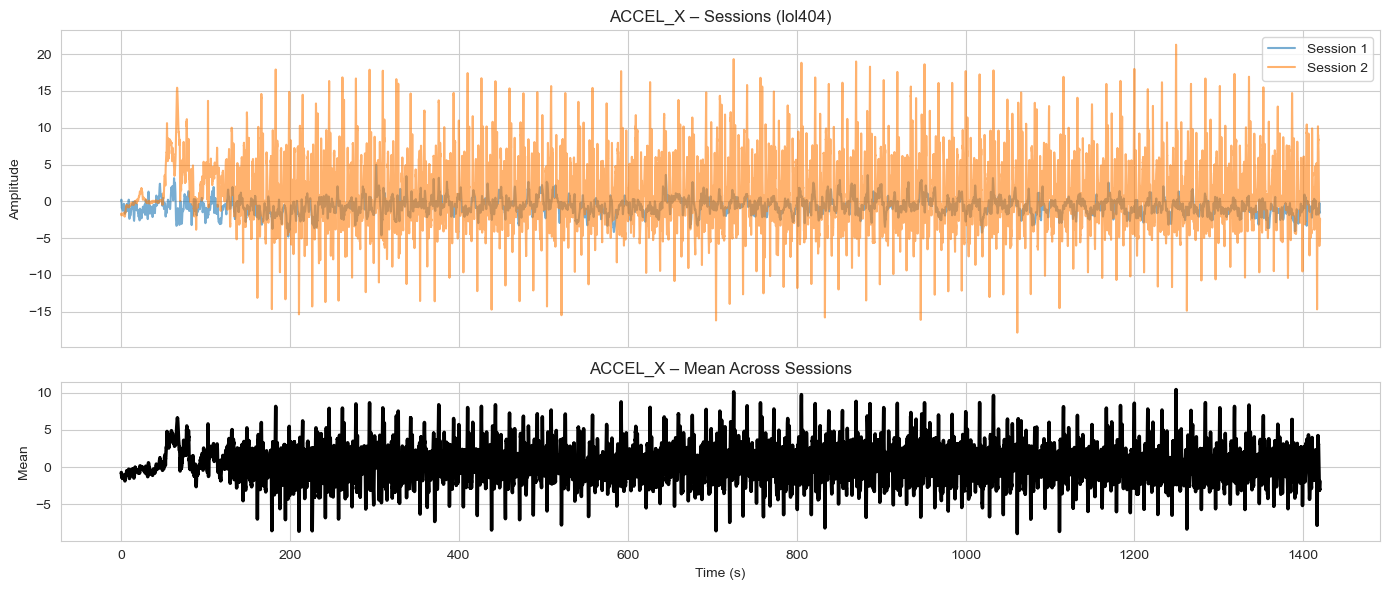

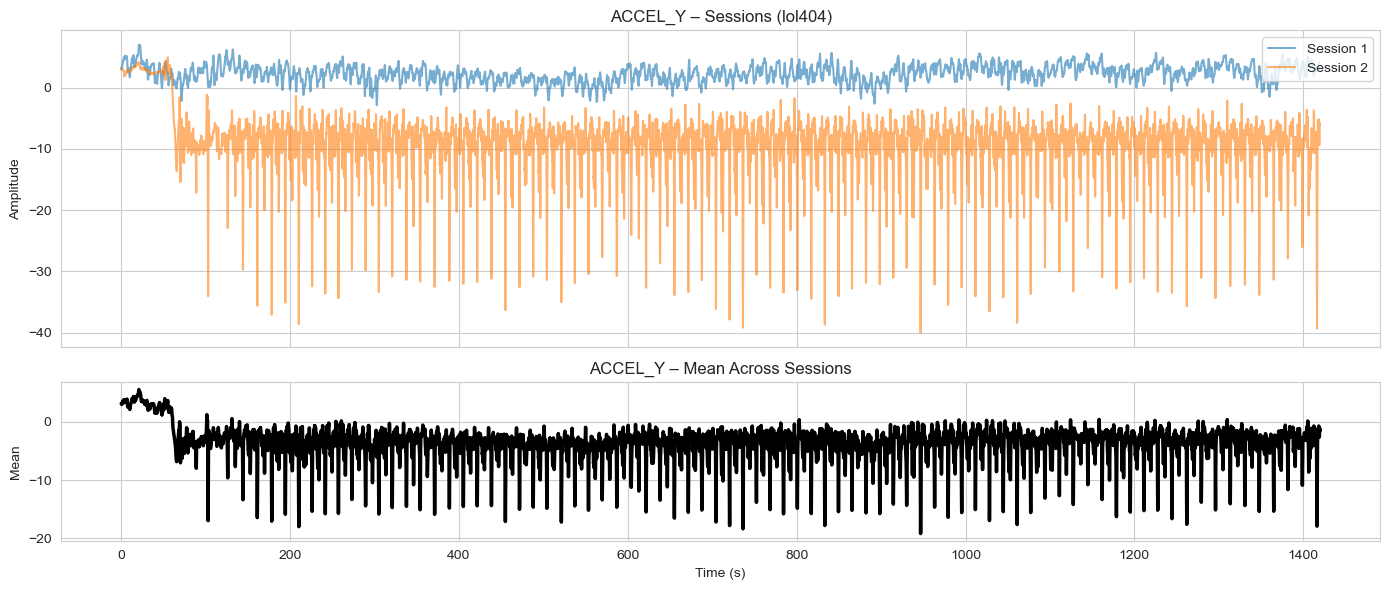

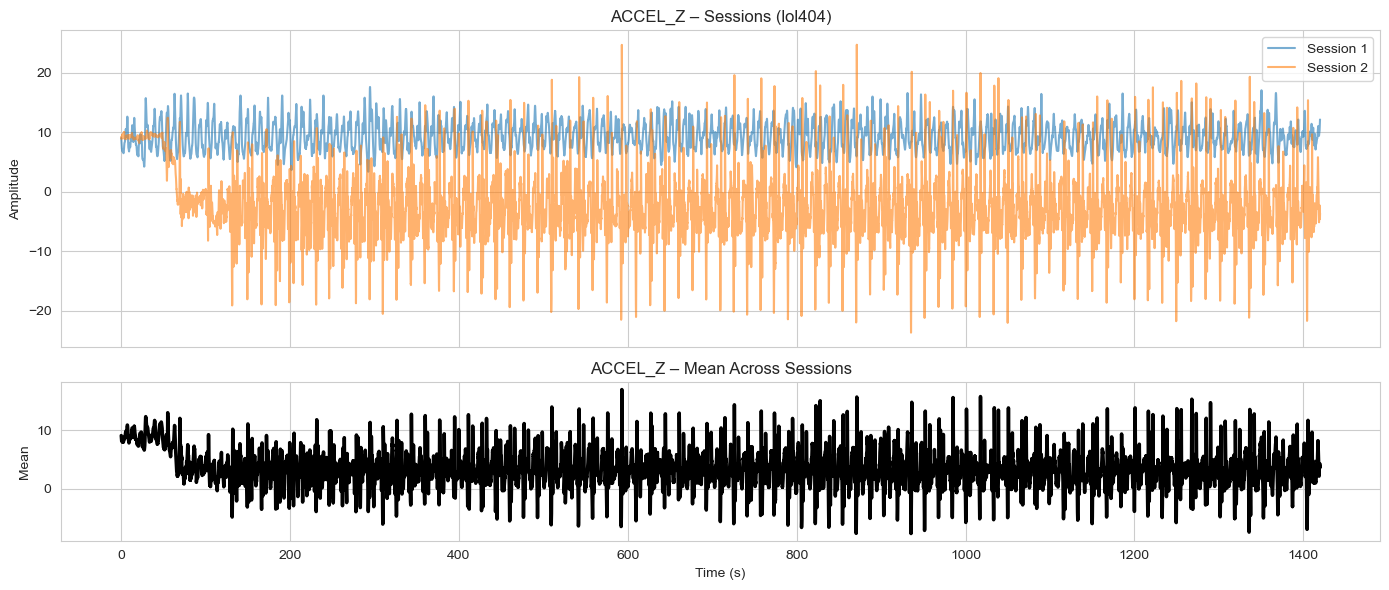

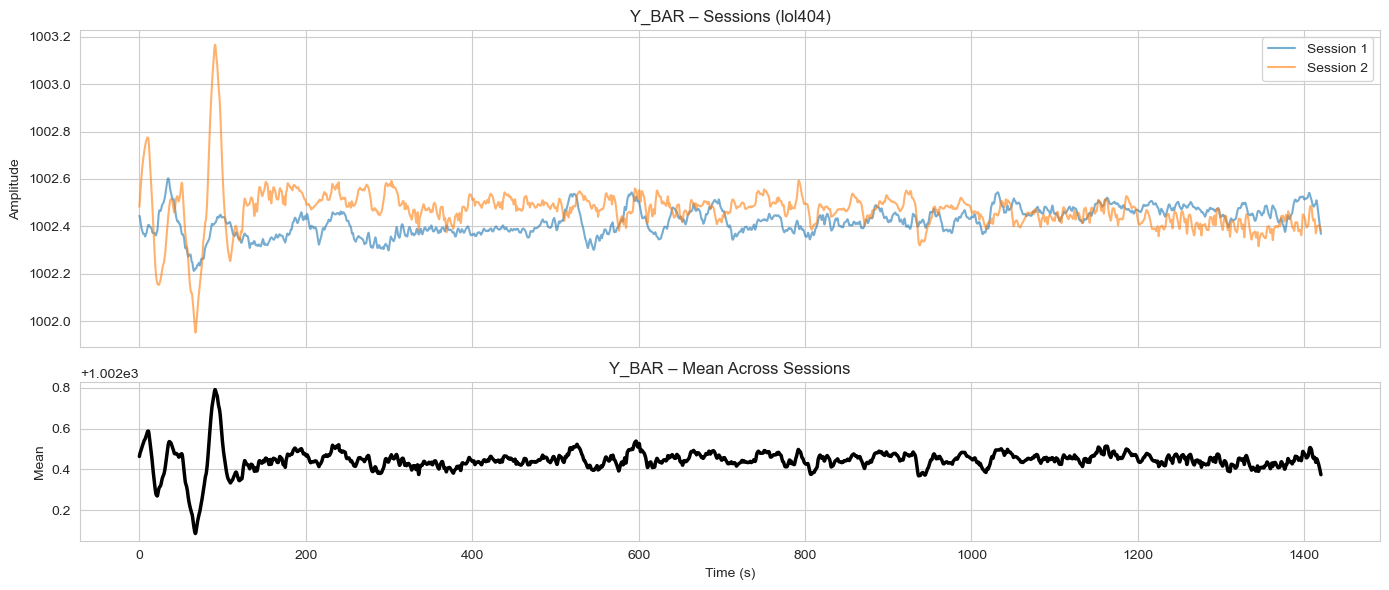

In [143]:
df_mean = plot_user_sessions_and_mean(df_raw,
                                      activity_name="Walking-flat-surface",
                                      user_id=my_netid,
                                      random=False)

🎲 Randomly selected user: nk428
✂️ Found 2 sessions for nk428
   Session 1: 21376 samples (~668.0s)
   Session 2: 11264 samples (~352.0s)


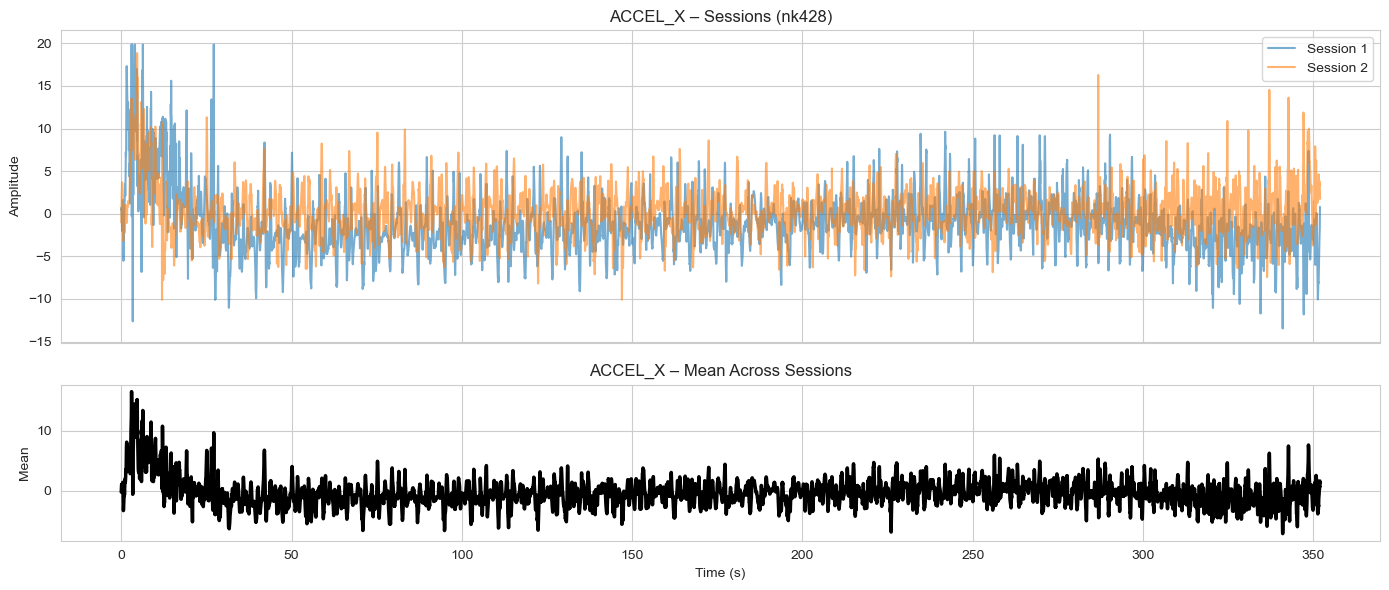

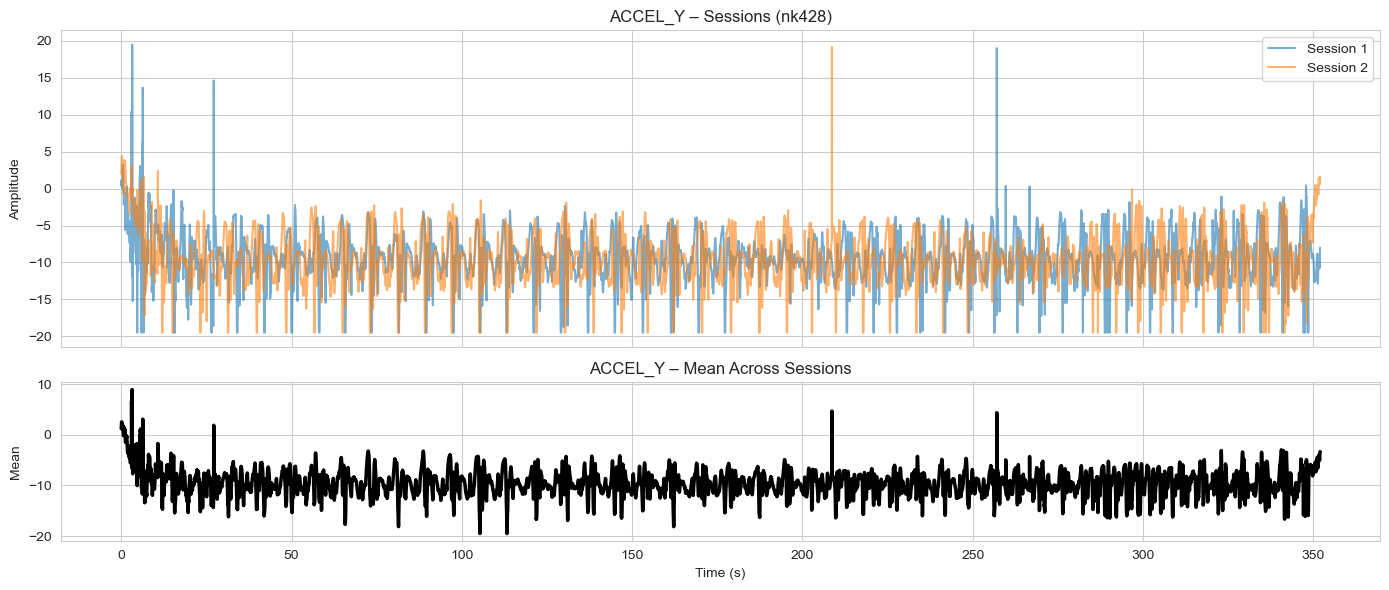

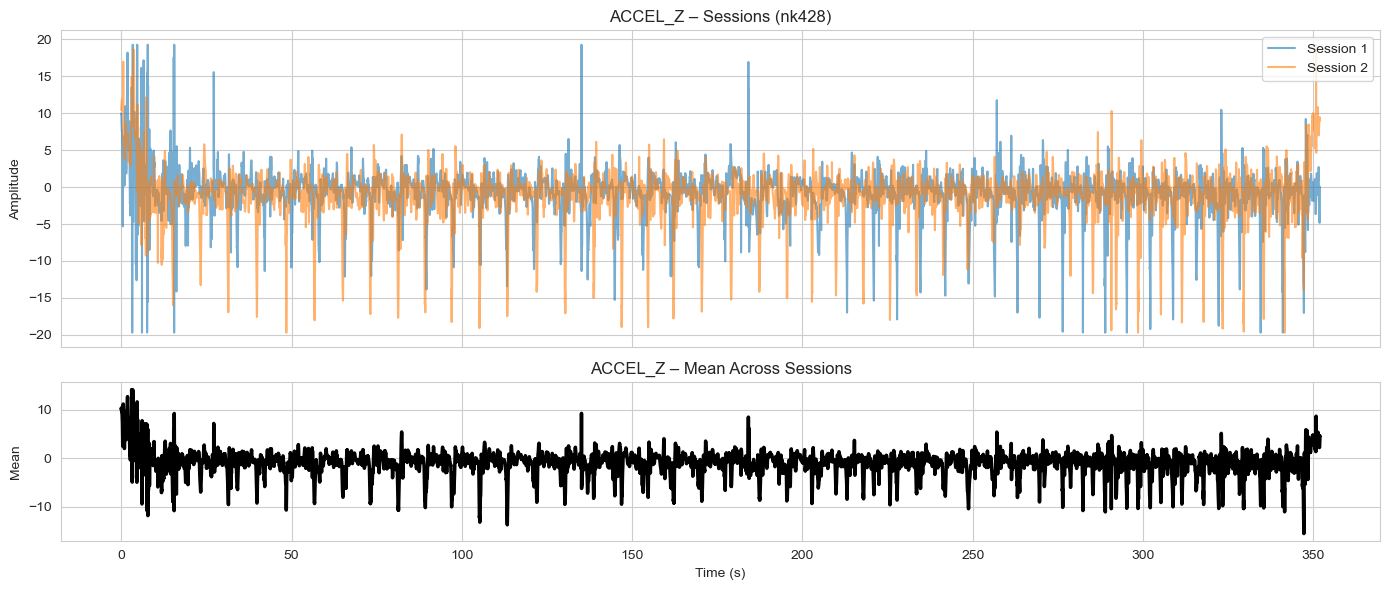

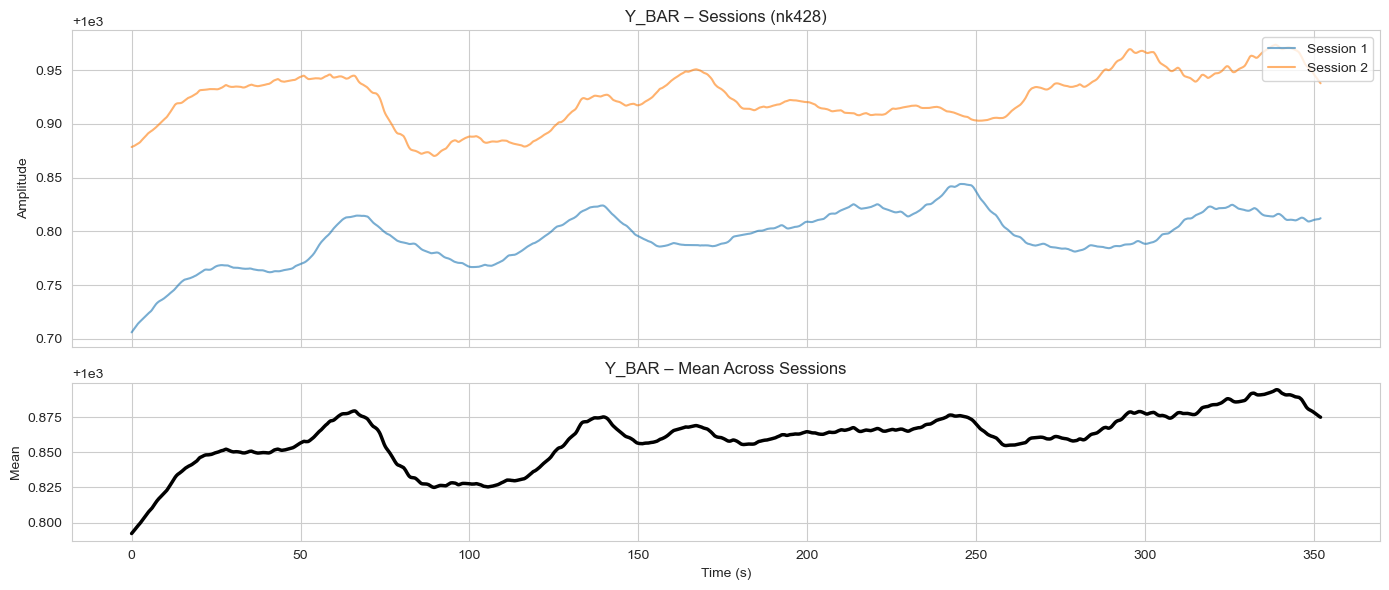

In [144]:
df_mean = plot_user_sessions_and_mean(df_raw,
                                      activity_name="Walking-flat-surface",
                                      random=True)

In [154]:
@ray.remote
def compute_user_mean_df(df, user_id, activity_name="Walking-flat-surface",
                         sensors=["accel_x", "accel_y", "accel_z", "y_bar"],
                         gap_multiplier=5, min_gap_seconds=1.0, sample_rate=32):
    """Compute per-user mean walking data in wide format matching df_raw."""
    sessions, _ = split_sessions(df, activity_name, user_id,
                                 random=False,
                                 gap_multiplier=gap_multiplier,
                                 min_gap_seconds=min_gap_seconds,
                                 sample_rate=sample_rate)

    if not sessions:
        return pd.DataFrame(columns=df.columns)

    mean_df, sessions, min_len = truncate_and_mean_sessions(sessions, sensors, sample_rate)
    if mean_df is None:
        return pd.DataFrame(columns=df.columns)

    # ✅ Real timestamp (start from first session timestamp)
    first_ts = sessions[0]["ts"].iloc[0]
    mean_df["ts"] = np.linspace(first_ts, first_ts + (min_len - 1) * (1000 / sample_rate), min_len)

    # ✅ Add metadata
    label_val = df.loc[
        (df["user"] == user_id) & (df["activity"] == activity_name), "label"
    ].iloc[0]

    mean_df["label"] = label_val
    mean_df["user"] = user_id
    mean_df["activity"] = activity_name

    # ✅ Arrange columns in the *exact same order*
    mean_df = mean_df[["ts"] + sensors + ["label", "user", "activity"]]
    return mean_df


# ------------------------------------------------------------
# Build walking means for all users
# ------------------------------------------------------------
def build_walking_means(df,
                        sensors=["accel_x", "accel_y", "accel_z", "y_bar"],
                        activity_name="Walking-flat-surface",
                        gap_multiplier=5, min_gap_seconds=1.0, sample_rate=32):
    """Parallelized mean walking builder — outputs wide-format DataFrame."""
    users = df[df["activity"] == activity_name]["user"].unique()
    print(f"🚶 Processing walking means for {len(users)} users...")

    tasks = [
        compute_user_mean_df.remote(
            df, user, activity_name, sensors,
            gap_multiplier, min_gap_seconds, sample_rate
        )
        for user in users
    ]
    results = ray.get(tasks)
    df_means = pd.concat(results, ignore_index=True)

    print(f"✅ Walking mean dataset created: {df_means.shape[0]} rows, {len(users)} users")
    return df_means


In [156]:
df_all_means = build_walking_means(df_raw,
                                    activity_name="Walking-flat-surface",
                                    sample_rate=32)

df_all_means

🚶 Processing walking means for 31 users...
✅ Walking mean dataset created: 843803 rows, 31 users


,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity
0,1.761523e+12,1.634556,-4.464425,5.136585,1001.950274,2,vbagdi,Walking-flat-surface
1,1.761523e+12,1.320123,-4.731102,6.465612,1001.950861,2,vbagdi,Walking-flat-surface
2,1.761523e+12,0.998545,-4.876345,7.460007,1001.951456,2,vbagdi,Walking-flat-surface
3,1.761523e+12,0.846092,-4.607288,6.028931,1001.952058,2,vbagdi,Walking-flat-surface
4,1.761523e+12,0.679347,-4.347755,4.267972,1001.952667,2,vbagdi,Walking-flat-surface
...,...,...,...,...,...,...,...,...
843798,1.760986e+12,-0.002393,0.585643,10.306485,1003.643091,2,xichen,Walking-flat-surface
843799,1.760986e+12,-0.021535,0.590429,10.320843,1003.641983,2,xichen,Walking-flat-surface
843800,1.760986e+12,-0.055035,0.591027,10.297512,1003.640898,2,xichen,Walking-flat-surface
843801,1.760986e+12,-0.069392,0.600598,10.287941,1003.639838,2,xichen,Walking-flat-surface


In [170]:
df_all_means[df_all_means['user'] == my_netid]

,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity
687845,1.761098e+12,-0.792922,3.179463,9.091829,1002.463809,2,lol404,Walking-flat-surface
687846,1.761098e+12,-0.750449,3.166901,9.032606,1002.464588,2,lol404,Walking-flat-surface
687847,1.761098e+12,-0.726820,3.145066,8.959027,1002.465350,2,lol404,Walking-flat-surface
687848,1.761098e+12,-0.731605,3.152544,8.890234,1002.466096,2,lol404,Walking-flat-surface
687849,1.761098e+12,-0.733998,3.155236,8.826225,1002.466824,2,lol404,Walking-flat-surface
...,...,...,...,...,...,...,...,...
733280,1.761100e+12,-2.312065,-1.365105,3.807878,1002.377321,2,lol404,Walking-flat-surface
733281,1.761100e+12,-2.226821,-1.390529,3.891029,1002.376625,2,lol404,Walking-flat-surface
733282,1.761100e+12,-2.103889,-1.422234,4.000201,1002.375937,2,lol404,Walking-flat-surface
733283,1.761100e+12,-2.030609,-1.440180,4.109374,1002.375257,2,lol404,Walking-flat-surface


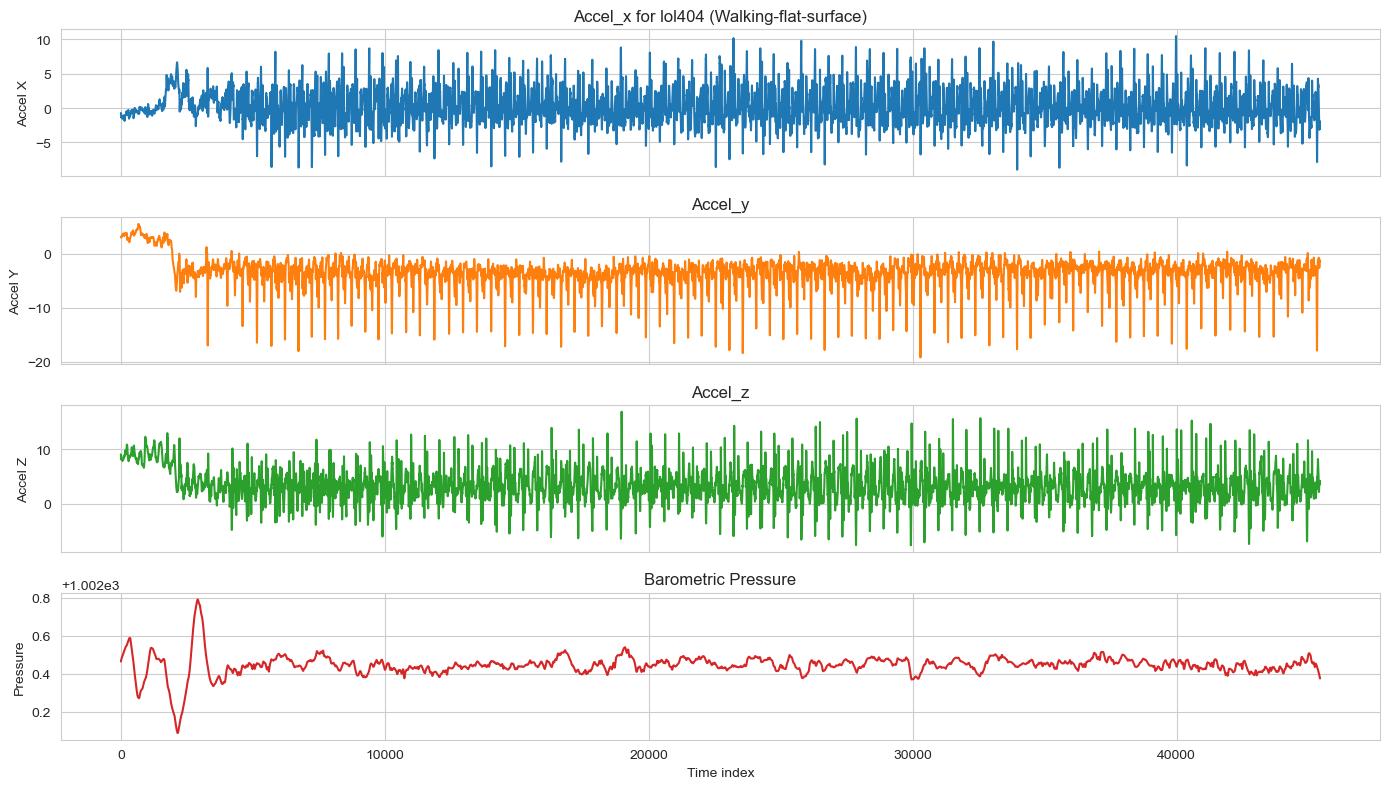

In [171]:
plot_user_activity(df_all_means, activity_name=activity_walk, user_id=my_netid, random=False)


🎲 Randomly selected user: aks249


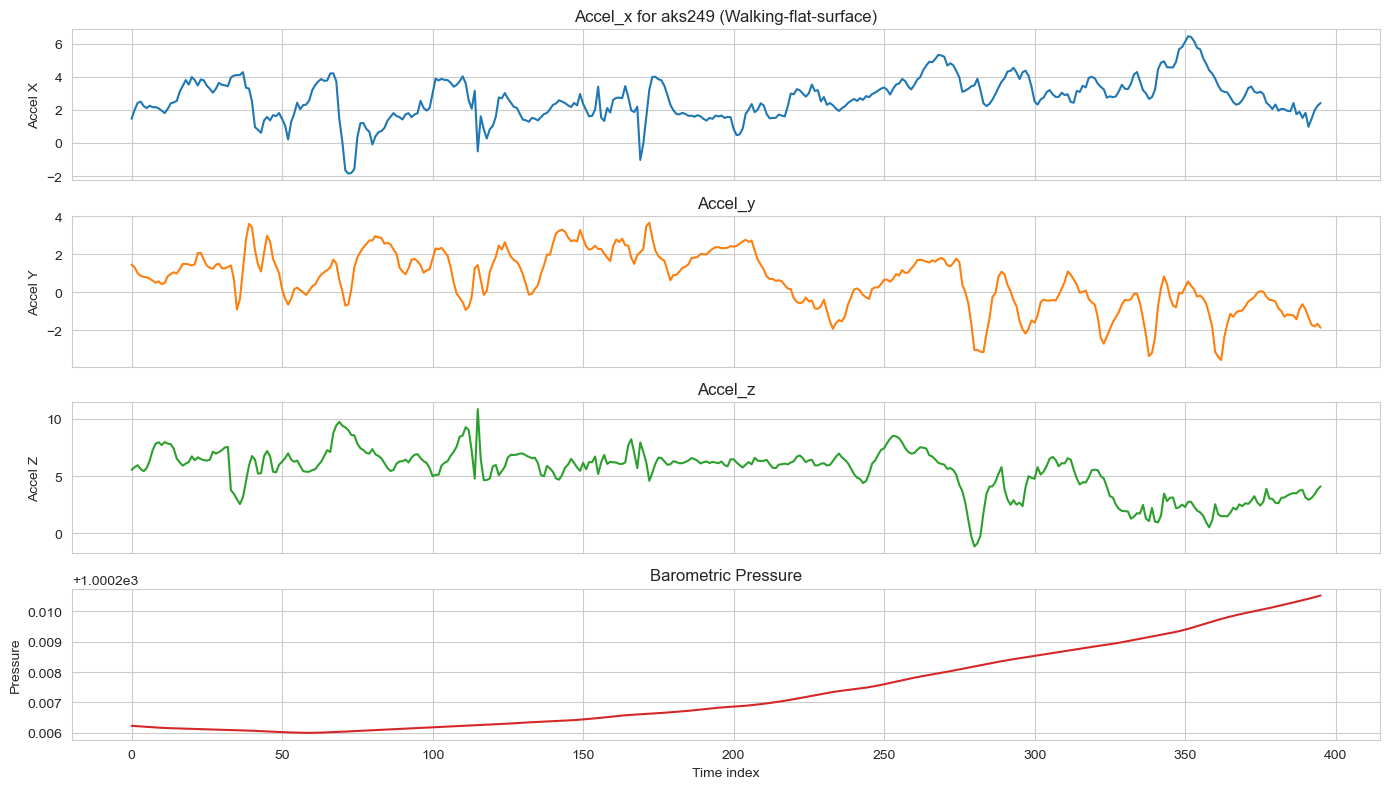

In [202]:
plot_user_activity(df_all_means, activity_walk, random=True)

In [203]:
def trim_edges(df, trim_frac):
    """
    Trim a fraction (default 10%) off both start and end of a user's data segment.
    Works with wide-format data (ts, accel_x, accel_y, accel_z, y_bar, label, user, activity).
    """
    n = len(df)
    if n < 10:
        return df  # too short to trim safely
    
    start = int(n * trim_frac)
    end = int(n * (1 - trim_frac))
    return df.iloc[start:end].reset_index(drop=True)

In [ ]:
trim = .1
df_allMeansTrimmed = df_all_means.groupby(['user', 'activity']).apply(trim_edges, trim_frac=trim).reset_index(drop=True)

In [ ]:
# Automatically compute lags farom number of samples and sample rate
def choose_lags(n_samples, sample_rate=32, seconds=2):
    """Compute recommended number of lags based on sample count and time horizon."""
    lags_boxjenkins = int(10 * np.log10(n_samples))
    lags_physical = int(seconds * sample_rate)
    return max(lags_boxjenkins, lags_physical)

# Visual method – choose p by ACF
def plot_acf_(series, sig_name, lags=20):
    """Plot ACF to visually inspect AR order p."""
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_acf(series, lags=lags, ax=ax)
    ax.set_title(f"{sig_name} ACF")
    plt.show()

#  Pure Brockwell root condition 
def brockwell_root_condition(phi):
    """
    Apply Brockwell & Davis (Ch.3) stationarity condition:
    Given AR coefficients φ₁...φ_p, check if all roots of
    1 - φ₁z - ... - φ_p z^p = 0 satisfy |z| > 1.
    """
    phi = np.asarray(phi, float)
    coeffs = np.concatenate(([1], -phi))
    roots = np.roots(coeffs)
    moduli = np.abs(roots)
    stationary = np.all(moduli > 1)

    print(f"φ = {np.round(phi, 4)}")
    for i, (r, m) in enumerate(zip(roots, moduli), 1):
        print(f"  Root {i}: {r:.4f} | |z|={m:.4f}")
    print("✅ Stationary" if stationary else "⚠️ Non-stationary")

    return {"phi": phi, "roots": roots, "moduli": moduli, "stationary": stationary}

#Estimate φ̂ from data if not provided
def estimate_phi_from_data(series, p=2):
    """Estimate AR(p) coefficients from data using least squares."""
    series = np.asarray(series, float)
    model = AutoReg(series, lags=p).fit()
    phi = model.params[1:]  # skip intercept
    print(f"Estimated φ̂ = {np.round(phi, 4)}")
    return phi

# Main Function: Run Brockwell test per user/activity/signal
def arma_stationarity_user(df, activity_name="Walking-flat-surface",
                           user_id=None, random=True, p=2,
                           phi_dict=None, sample_rate=32, seconds=2):
    """
    Test for accel_x, accel_y, accel_z, and y_bar.
    - If phi_dict is provided, uses those φ values directly (no fitting).
    - Otherwise, estimates φ̂ from data (least squares) for each signal.
    - Automatically determines lags from sample count and sampling rate.
    """
    # Pick user
    if random or user_id is None:
        users = df[df["activity"] == activity_name]["user"].unique()
        user_id = np.random.choice(users)
        print(f"🎲 Randomly selected user: {user_id}")
    else:
        print(f"👤 Using specified user: {user_id}")

    results = {}
    for sig in ["accel_x", "accel_y", "accel_z", "y_bar"]:
        series = df[(df["user"] == user_id) &
                    (df["activity"] == activity_name)][sig].dropna()

        if len(series) < p + 5:
            print(f"⚠️ Not enough data for {sig}")
            continue

        # Automatically choose number of lags
        lags = choose_lags(len(series), sample_rate=sample_rate, seconds=seconds)
        print(f"\n📈 ACF for {sig.upper()} | {lags} lags (auto)")

        # Plot ACF
        plot_acf_(series, sig_name=sig, lags=lags)

        # Estimate or use provided φ
        if phi_dict and sig in phi_dict:
            phi = phi_dict[sig]
            print(f"\n📘 {sig.upper()} | Using provided φ = {phi} | User: {user_id}")
        else:
            print(f"\n📘 {sig.upper()} | Estimating φ̂ | AR({p}) | User: {user_id}")
            phi = estimate_phi_from_data(series, p=p)

        # Brockwell root condition
        results[sig] = brockwell_root_condition(phi)

    return results

👤 Using specified user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


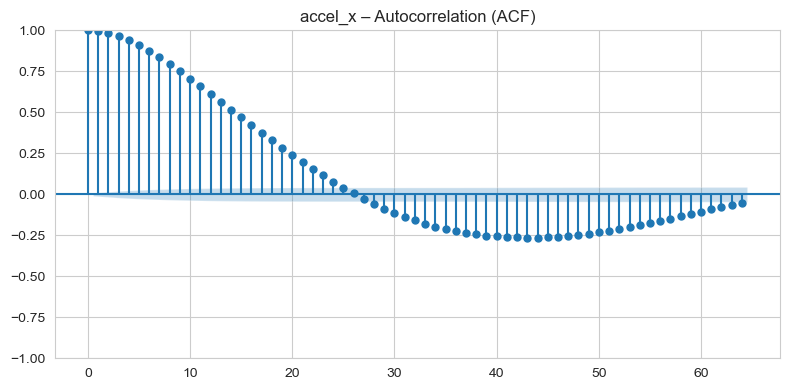


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.8692 -0.8774]
φ = [ 1.8692 -0.8774]
  Root 1: 0.9346+0.0624j | |z|=0.9367
  Root 2: 0.9346-0.0624j | |z|=0.9367
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


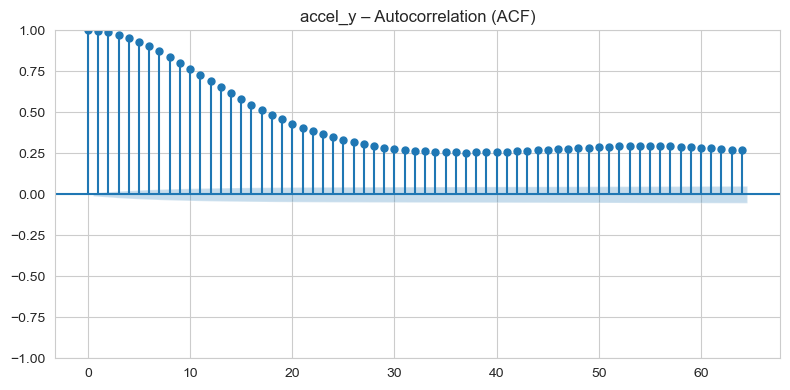


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.9606 -0.9665]
φ = [ 1.9606 -0.9665]
  Root 1: 0.9803+0.0741j | |z|=0.9831
  Root 2: 0.9803-0.0741j | |z|=0.9831
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


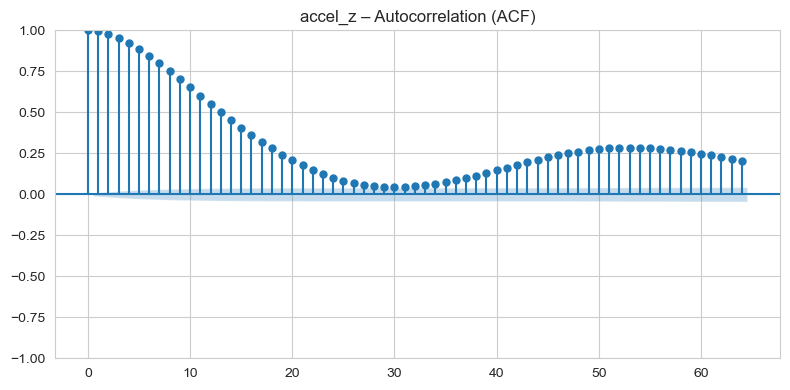


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.8842 -0.8947]
φ = [ 1.8842 -0.8947]
  Root 1: 0.9421+0.0848j | |z|=0.9459
  Root 2: 0.9421-0.0848j | |z|=0.9459
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


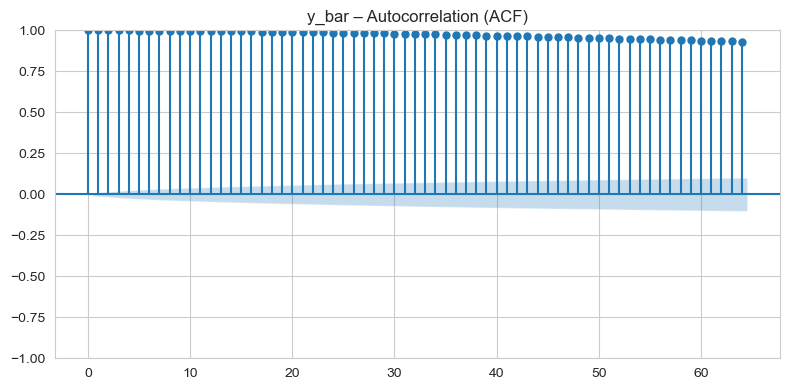


📘 Y_BAR | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.9987 -0.9988]
φ = [ 1.9987 -0.9988]
  Root 1: 0.9994+0.0070j | |z|=0.9994
  Root 2: 0.9994-0.0070j | |z|=0.9994
⚠️ Non-stationary


{'accel_x': {'phi': array([ 1.86920929, -0.87737387]),
  'roots': array([0.93460465+0.06235405j, 0.93460465-0.06235405j]),
  'moduli': array([0.93668238, 0.93668238]),
  'stationary': False},
 'accel_y': {'phi': array([ 1.9606433 , -0.96651446]),
  'roots': array([0.98032165+0.07405347j, 0.98032165-0.07405347j]),
  'moduli': array([0.98311467, 0.98311467]),
  'stationary': False},
 'accel_z': {'phi': array([ 1.88419593, -0.89474364]),
  'roots': array([0.94209797+0.08482369j, 0.94209797-0.08482369j]),
  'moduli': array([0.9459089, 0.9459089]),
  'stationary': False},
 'y_bar': {'phi': array([ 1.99870188, -0.99875149]),
  'roots': array([0.99935094+0.00701346j, 0.99935094-0.00701346j]),
  'moduli': array([0.99937555, 0.99937555]),
  'stationary': False}}

In [185]:
arma_stationarity_user(df_all_means, activity_walk, user_id=my_netid, random=False)

🎲 Randomly selected user: ktc36

📈 ACF for ACCEL_X | 64 lags (auto)


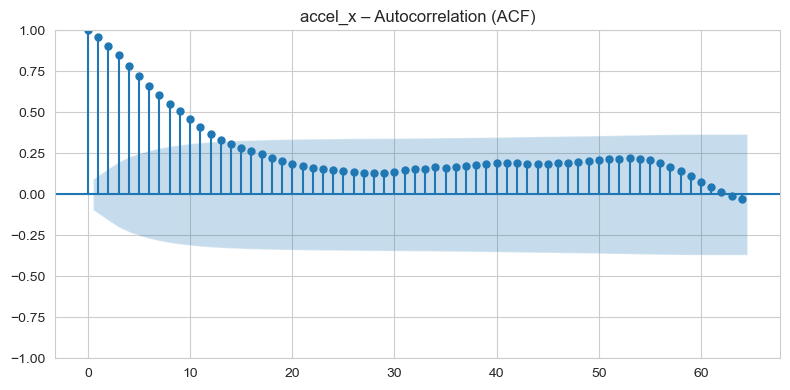


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: ktc36
Estimated φ̂ = [ 1.1778 -0.2238]
φ = [ 1.1778 -0.2238]
  Root 1: 0.9397 | |z|=0.9397
  Root 2: 0.2381 | |z|=0.2381
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


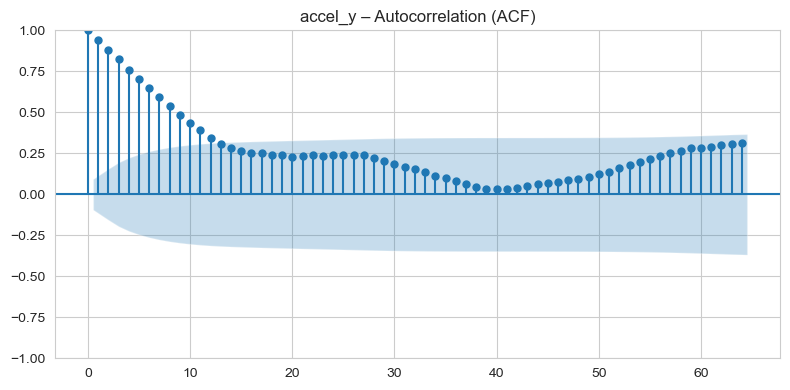


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: ktc36
Estimated φ̂ = [ 0.9999 -0.0579]
φ = [ 0.9999 -0.0579]
  Root 1: 0.9382 | |z|=0.9382
  Root 2: 0.0617 | |z|=0.0617
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


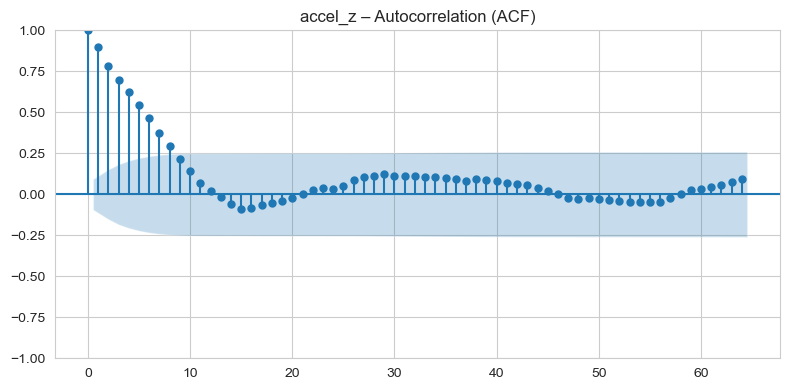


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: ktc36
Estimated φ̂ = [ 1.0445 -0.1595]
φ = [ 1.0445 -0.1595]
  Root 1: 0.8587 | |z|=0.8587
  Root 2: 0.1857 | |z|=0.1857
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


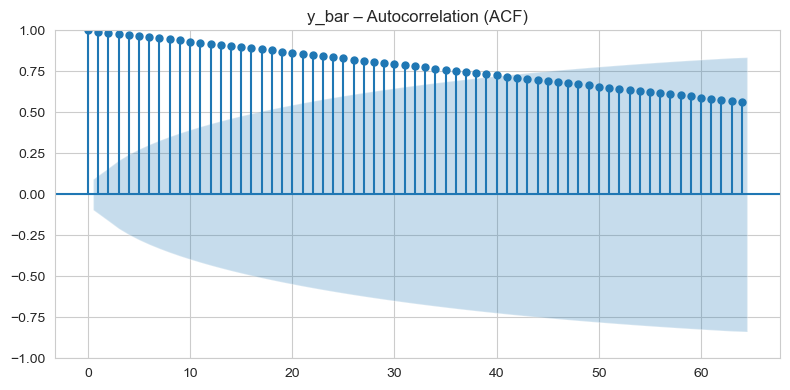


📘 Y_BAR | Estimating φ̂ | AR(2) | User: ktc36
Estimated φ̂ = [ 1.9989 -0.9989]
φ = [ 1.9989 -0.9989]
  Root 1: 1.0004 | |z|=1.0004
  Root 2: 0.9985 | |z|=0.9985
⚠️ Non-stationary


{'accel_x': {'phi': array([ 1.17784716, -0.22376895]),
  'roots': array([0.93972556, 0.2381216 ]),
  'moduli': array([0.93972556, 0.2381216 ]),
  'stationary': False},
 'accel_y': {'phi': array([ 0.99988636, -0.05790908]),
  'roots': array([0.93816015, 0.06172622]),
  'moduli': array([0.93816015, 0.06172622]),
  'stationary': False},
 'accel_z': {'phi': array([ 1.04446252, -0.15950195]),
  'roots': array([0.85871832, 0.1857442 ]),
  'moduli': array([0.85871832, 0.1857442 ]),
  'stationary': False},
 'y_bar': {'phi': array([ 1.99889398, -0.99889347]),
  'roots': array([1.00035095, 0.99854303]),
  'moduli': array([1.00035095, 0.99854303]),
  'stationary': False}}

In [186]:
arma_stationarity_user(df_all_means, activity_walk,random=True)

In [129]:
def difference_all_sensors(df, activity_name="Walking-flat-surface",
                           user_id=None, random=True, order=1):
    """
    Create a new DataFrame with all four sensors differenced for one user/activity.
    - If random=True, randomly selects a user who performed that activity.
    - Keeps the same structure and column names so it can be used directly
      with arma_stationarity_user() or other tests.
    """
    sensors = ["accel_x", "accel_y", "accel_z", "y_bar"]

    # Random user selection
    if random or user_id is None:
        users = df[df["activity"] == activity_name]["user"].unique()
        user_id = np.random.choice(users)
        print(f"🎲 Randomly selected user: {user_id}")
    else:
        print(f"👤 Using specified user: {user_id}")

    # Filter for that user/activity
    df_user = df[(df["user"] == user_id) &(df["activity"] == activity_name)].copy()

    # Apply differencing
    for sig in sensors:
        df_user[sig] = df_user[sig].diff(order)

    # Drop rows with NaNs created by differencing
    df_user = df_user.dropna(subset=sensors).reset_index(drop=True)

    return df_user

In [187]:
df_diffMe= difference_all_sensors(df_all_means, activity_walk, my_netid,random=False, order=1)
df_diffMe

👤 Using specified user: lol404


,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity
0,1.761098e+12,0.042473,-0.012562,-0.059223,0.000779,2,lol404,Walking-flat-surface
1,1.761098e+12,0.023629,-0.021834,-0.073579,0.000762,2,lol404,Walking-flat-surface
2,1.761098e+12,-0.004786,0.007478,-0.068793,0.000745,2,lol404,Walking-flat-surface
3,1.761098e+12,-0.002393,0.002692,-0.064008,0.000728,2,lol404,Walking-flat-surface
4,1.761098e+12,-0.021236,-0.006580,-0.047557,0.000711,2,lol404,Walking-flat-surface
...,...,...,...,...,...,...,...,...
45434,1.761100e+12,0.108873,-0.033499,0.064307,-0.000703,2,lol404,Walking-flat-surface
45435,1.761100e+12,0.085244,-0.025424,0.083151,-0.000696,2,lol404,Walking-flat-surface
45436,1.761100e+12,0.122931,-0.031705,0.109173,-0.000688,2,lol404,Walking-flat-surface
45437,1.761100e+12,0.073280,-0.017946,0.109172,-0.000680,2,lol404,Walking-flat-surface


👤 Using specified user: lol404

📈 ACF for ACCEL_X | 64 lags (auto)


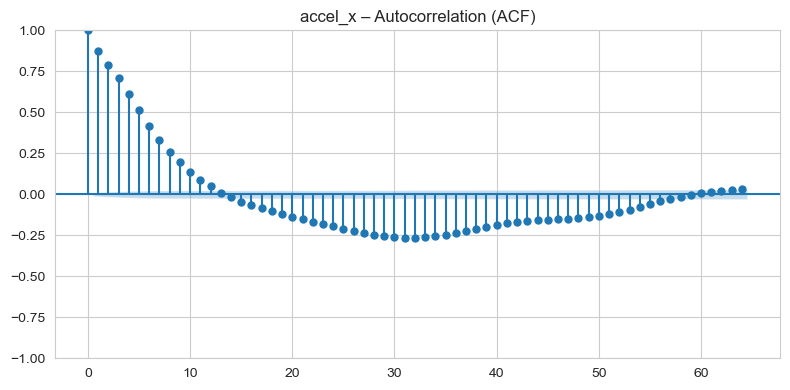


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [0.7846 0.1015]
φ = [0.7846 0.1015]
  Root 1: 0.8977 | |z|=0.8977
  Root 2: -0.1131 | |z|=0.1131
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


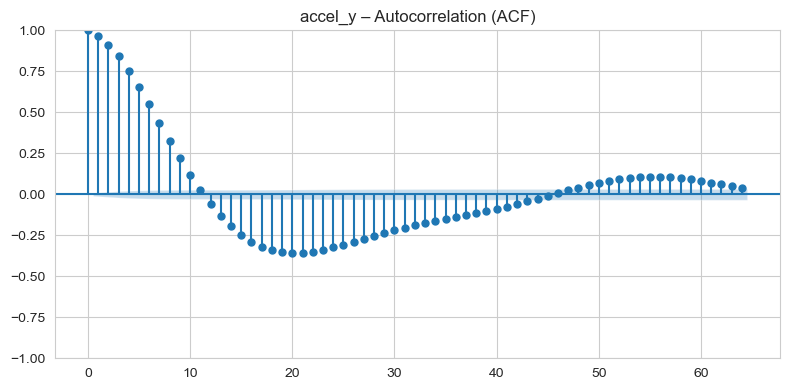


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.1877 -0.2325]
φ = [ 1.1877 -0.2325]
  Root 1: 0.9405 | |z|=0.9405
  Root 2: 0.2473 | |z|=0.2473
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


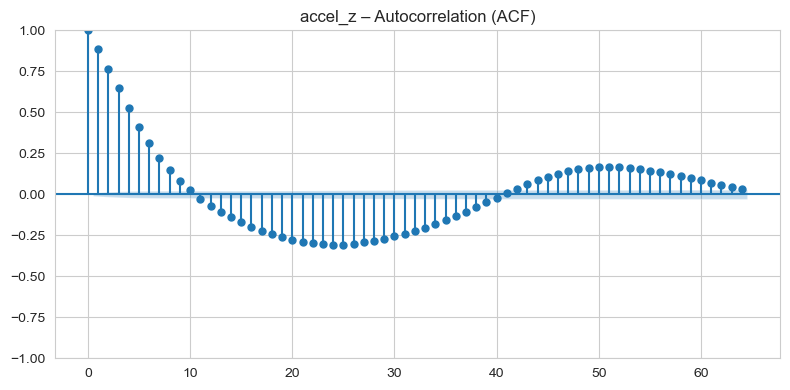


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.005  -0.1299]
φ = [ 1.005  -0.1299]
  Root 1: 0.8527 | |z|=0.8527
  Root 2: 0.1523 | |z|=0.1523
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


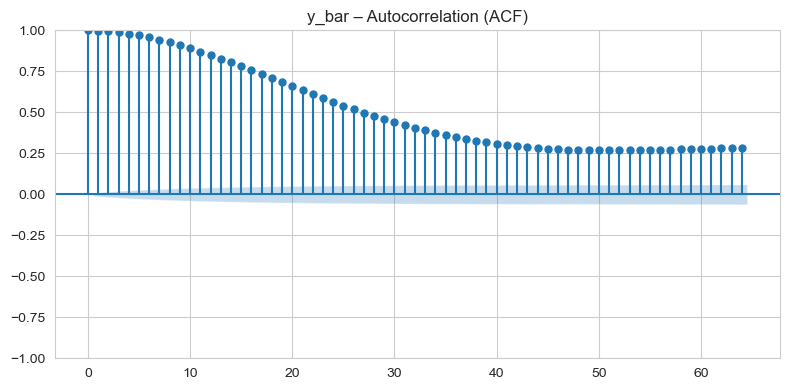


📘 Y_BAR | Estimating φ̂ | AR(2) | User: lol404
Estimated φ̂ = [ 1.9609 -0.9634]
φ = [ 1.9609 -0.9634]
  Root 1: 0.9805+0.0461j | |z|=0.9815
  Root 2: 0.9805-0.0461j | |z|=0.9815
⚠️ Non-stationary


{'accel_x': {'phi': array([0.78461255, 0.10153848]),
  'roots': array([ 0.89771967, -0.11310711]),
  'moduli': array([0.89771967, 0.11310711]),
  'stationary': False},
 'accel_y': {'phi': array([ 1.18772977, -0.23254954]),
  'roots': array([0.94045681, 0.24727296]),
  'moduli': array([0.94045681, 0.24727296]),
  'stationary': False},
 'accel_z': {'phi': array([ 1.00504093, -0.12988324]),
  'roots': array([0.85272551, 0.15231542]),
  'moduli': array([0.85272551, 0.15231542]),
  'stationary': False},
 'y_bar': {'phi': array([ 1.96092056, -0.96343015]),
  'roots': array([0.98046028+0.04612797j, 0.98046028-0.04612797j]),
  'moduli': array([0.98154478, 0.98154478]),
  'stationary': False}}

In [188]:
arma_stationarity_user(df_diffMe,activity_walk,my_netid,random=False,p=2)

In [189]:
df_diffRando = difference_all_sensors(df_raw, activity_walk, random=True, order=1)
str_diffRando = df_diffRando["user"][0]
df_diffRando

🎲 Randomly selected user: jps394


,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity
0,1.457122e+12,0.499878,0.095215,0.035706,-0.000019,2,jps394,Walking-flat-surface
1,1.457122e+12,0.295166,0.185669,0.073791,-0.000019,2,jps394,Walking-flat-surface
2,1.457122e+12,0.366577,0.330872,0.530823,-0.000019,2,jps394,Walking-flat-surface
3,1.457122e+12,0.097595,0.385620,0.135681,-0.000019,2,jps394,Walking-flat-surface
4,1.457122e+12,-0.514160,-0.664124,-0.095215,-0.000019,2,jps394,Walking-flat-surface
...,...,...,...,...,...,...,...,...
51962,1.457123e+12,0.026184,0.157104,-0.235656,-0.000020,2,jps394,Walking-flat-surface
51963,1.457123e+12,0.054749,0.004761,-0.040467,-0.000020,2,jps394,Walking-flat-surface
51964,1.457123e+12,-0.114258,-0.042847,-0.054748,-0.000020,2,jps394,Walking-flat-surface
51965,1.457123e+12,-0.071411,-0.145203,-0.028565,-0.000020,2,jps394,Walking-flat-surface


👤 Using specified user: jps394

📈 ACF for ACCEL_X | 64 lags (auto)


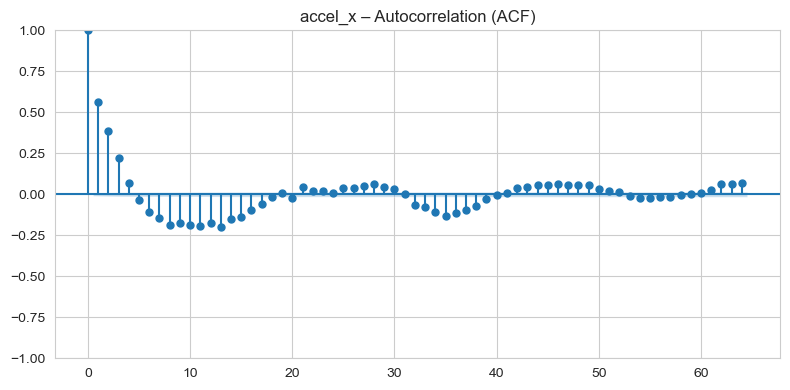


📘 ACCEL_X | Estimating φ̂ | AR(2) | User: jps394
Estimated φ̂ = [0.5028 0.1043]
φ = [0.5028 0.1043]
  Root 1: 0.6607 | |z|=0.6607
  Root 2: -0.1579 | |z|=0.1579
⚠️ Non-stationary

📈 ACF for ACCEL_Y | 64 lags (auto)


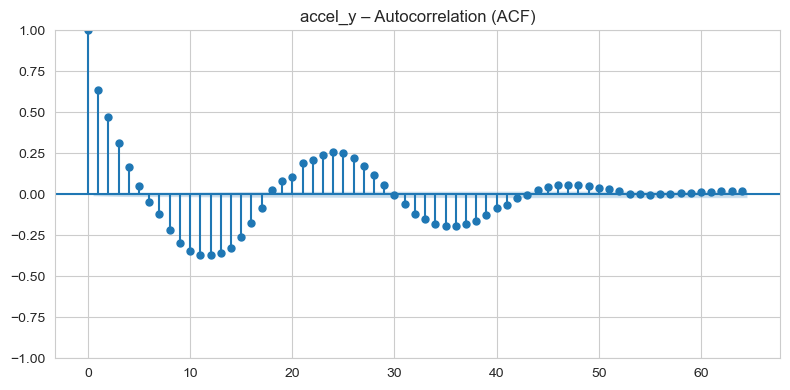


📘 ACCEL_Y | Estimating φ̂ | AR(2) | User: jps394
Estimated φ̂ = [0.5591 0.1192]
φ = [0.5591 0.1192]
  Root 1: 0.7238 | |z|=0.7238
  Root 2: -0.1647 | |z|=0.1647
⚠️ Non-stationary

📈 ACF for ACCEL_Z | 64 lags (auto)


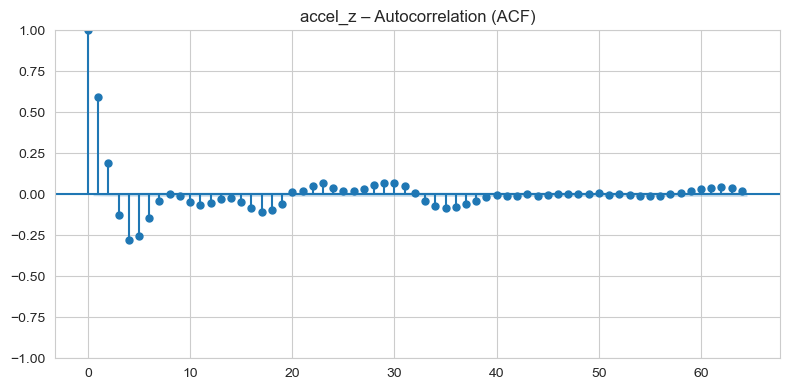


📘 ACCEL_Z | Estimating φ̂ | AR(2) | User: jps394
Estimated φ̂ = [ 0.743  -0.2484]
φ = [ 0.743  -0.2484]
  Root 1: 0.3715+0.3323j | |z|=0.4984
  Root 2: 0.3715-0.3323j | |z|=0.4984
⚠️ Non-stationary

📈 ACF for Y_BAR | 64 lags (auto)


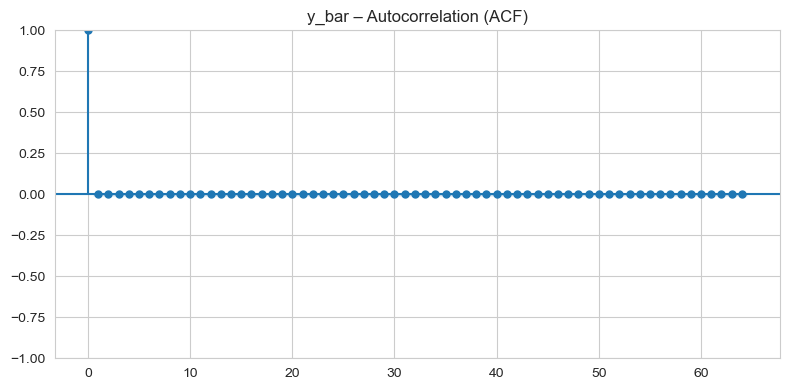


📘 Y_BAR | Estimating φ̂ | AR(2) | User: jps394
Estimated φ̂ = [0.0001 0.0001]
φ = [0.0001 0.0001]
  Root 1: 0.0095 | |z|=0.0095
  Root 2: -0.0094 | |z|=0.0094
⚠️ Non-stationary


{'accel_x': {'phi': array([0.5027625 , 0.10433764]),
  'roots': array([ 0.66068575, -0.15792325]),
  'moduli': array([0.66068575, 0.15792325]),
  'stationary': False},
 'accel_y': {'phi': array([0.55906499, 0.11920126]),
  'roots': array([ 0.7237618 , -0.16469681]),
  'moduli': array([0.7237618 , 0.16469681]),
  'stationary': False},
 'accel_z': {'phi': array([ 0.74302052, -0.24842706]),
  'roots': array([0.37151026+0.33227576j, 0.37151026-0.33227576j]),
  'moduli': array([0.49842457, 0.49842457]),
  'stationary': False},
 'y_bar': {'phi': array([8.85342807e-05, 8.88738058e-05]),
  'roots': array([ 0.00947166, -0.00938313]),
  'moduli': array([0.00947166, 0.00938313]),
  'stationary': False}}

In [190]:
arma_stationarity_user(df_diffRando, activity_walk, str_diffRando, random=False)

TO DO
 
Do you see any interesting trends while observing signals from different activities (like walking, running stationary) ? Explain what you see. 
Can you think of any specific feature that might help us to differentiate among different activities? You will write a paragraph on this.

Comparing walking to running, the accelerometer signal during running is much more jagged, while the walking signal appears smoother and more rhythmic. This suggests that measures of dispersion—such as the range between peaks and troughs—could help distinguish between these activities. In particular, variations along the z-axis (vertical motion) seem especially informative since running involves more pronounced vertical oscillations. I forgot to collect the stationary data, my mistake, I did all the others, but I expect it to show minimal variation and very low amplitude compared to the others.

In [82]:
x_list_train = []
y_list_train = []
z_list_train = []
b_list_train = []
train_labels = []
train_participants = []

# TO DO
# Similarly create test list
x_list_test = []
y_list_test = []
z_list_test = []
b_list_test = []
test_labels = []
test_participants = []


# Setting window size of 100 datapoints with an overlap of 50%
window_size = 100
step_size = 50

TO DO

You will extract features from the accelerometer magnitude and barometric pressure time series data. The windowing will be done by a sliding window where the length of the window will be 100 data points with an overlap of 50%. 

In [86]:
df_train

,ts,accel_x,accel_y,accel_z,y_bar,label,user,activity
0,1.761522e+12,-0.443601,-0.537366,9.946635,1001.999464,1.0,vbagdi,Stationary
1,1.761522e+12,-0.381671,-0.494507,10.008340,1001.999263,1.0,vbagdi,Stationary
2,1.761522e+12,-0.415024,-0.532604,9.908663,1001.999056,1.0,vbagdi,Stationary
3,1.761522e+12,-0.395971,-0.513556,9.908663,1001.998843,1.0,vbagdi,Stationary
4,1.761522e+12,-0.386446,-0.513557,9.918155,1001.998624,1.0,vbagdi,Stationary
...,...,...,...,...,...,...,...,...
7091067,1.760986e+12,2.644069,-0.965504,7.988439,1004.050420,7.0,xichen,Elevator-down
7091068,1.760986e+12,2.654238,-0.922433,7.983055,1004.051759,7.0,xichen,Elevator-down
7091069,1.760986e+12,2.673979,-0.869791,8.021339,1004.053094,7.0,xichen,Elevator-down
7091070,1.760986e+12,2.674577,-0.816551,8.044670,1004.054423,7.0,xichen,Elevator-down


In [88]:
# creating overlaping windows of size 100
# Train windows
for i in range(0, df_train.shape[0] - window_size, step_size):
    window = df_train.iloc[i:i + window_size]
    x_list_train.append(window['accel_x'].values)
    y_list_train.append(window['accel_y'].values)
    z_list_train.append(window['accel_z'].values)
    b_list_train.append(window['y_bar'].values)
    train_labels.append(stats.mode(window['label'], keepdims=True)[0][0])
    train_participants.append(window["user"].mode()[0])
train_labels
   

[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0

In [89]:
# creating overlaping windows of size 100
# Test windows
for i in range(0, df_test.shape[0] - window_size, step_size):
    window = df_test.iloc[i:i + window_size]
    x_list_test.append(window['accel_x'].values)
    y_list_test.append(window['accel_y'].values)
    z_list_test.append(window['accel_z'].values)
    b_list_test.append(window['y_bar'].values)
    test_labels.append(stats.mode(window['label'], keepdims=True)[0][0])
    test_participants.append(window['user'].mode()[0])
test_labels

[2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0

TO DO

Compute Different Time Domain features

In [91]:
# Computing Time Domain Features
# Slope
def compute_slope(sig):
    """Slope (fit a line and estimate the m from y = mx + c)."""
    return np.polyfit(np.arange(len(sig)), sig, 1)[0]

# Find Peaks
def find_peaks_signal(sig):
    """Find Peaks."""
    peaks, _ = signal.find_peaks(sig)
    return peaks

# Combined Peak Features
def compute_peak_features(sig):
    """Return number of peaks, mean peak value, and mean peak distance."""
    peaks = find_peaks_signal(sig)
    num_peaks = len(peaks)
    mean_peak_val = np.mean(sig[peaks]) if num_peaks > 0 else 0
    mean_peak_dist = np.mean(np.diff(peaks)) if num_peaks > 1 else 0
    return num_peaks, mean_peak_val, mean_peak_dist

# Remote Function
@ray.remote
def compute_time_features(x, y, z, b, label,participant):
    mean_x, mean_y, mean_z, mean_b = np.mean(x), np.mean(y), np.mean(z), np.mean(b) # Mean
    std_x, std_y, std_z, std_b = np.std(x), np.std(y), np.std(z), np.std(b) # Standard Deviation
    skew_x, skew_y, skew_z, skew_b = skew(x), skew(y), skew(z), skew(b) # Skewness 
    diff_x, diff_y, diff_z, diff_b = np.ptp(x), np.ptp(y), np.ptp(z), np.ptp(b) # Difference between max and min value
    kurt_x, kurt_y, kurt_z, kurt_b = kurtosis(x), kurtosis(y), kurtosis(z), kurtosis(b) # Kurtosis
    energy_x, energy_y, energy_z, energy_b = np.sum(x**2), np.sum(y**2), np.sum(z**2), np.sum(b**2) # Energy

    # Slope + Peak Features
    slope_x, slope_y, slope_z, slope_b = compute_slope(x), compute_slope(y), compute_slope(z), compute_slope(b) # Slope (fit a line and estimate the m from y = mx + c)
    num_peaks_x, mean_peak_val_x, mean_peak_dist_x = compute_peak_features(x) # Number of Peaks, Mean Peak Value, Mean Peak Distance for x
    num_peaks_y, mean_peak_val_y, mean_peak_dist_y = compute_peak_features(y) # Number of Peaks, Mean Peak Value, Mean Peak Distance for y
    num_peaks_z, mean_peak_val_z, mean_peak_dist_z = compute_peak_features(z) # Number of Peaks, Mean Peak Value, Mean Peak Distance for z
    num_peaks_b, mean_peak_val_b, mean_peak_dist_b = compute_peak_features(b) # Number of Peaks, Mean Peak Value, Mean Peak Distance for b

    dict_features = {
        "label": label, "participant": participant, # Label & Participant
        "mean_x": mean_x, "mean_y": mean_y, "mean_z": mean_z, "mean_b": mean_b, # Mean
        "std_x": std_x, "std_y": std_y, "std_z": std_z, "std_b": std_b, # Standard Deviation
        "skew_x": skew_x, "skew_y": skew_y, "skew_z": skew_z, "skew_b": skew_b, # Skewness
        "diff_x": diff_x, "diff_y": diff_y, "diff_z": diff_z, "diff_b": diff_b, # Difference between max and min value
        "kurt_x": kurt_x, "kurt_y": kurt_y, "kurt_z": kurt_z, "kurt_b": kurt_b, # Kurtosis
        "energy_x": energy_x, "energy_y": energy_y, "energy_z": energy_z, "energy_b": energy_b, # Energy
        "slope_x": slope_x, "slope_y": slope_y, "slope_z": slope_z, "slope_b": slope_b, # Slope (fit a line and estimate the m from y = mx + c)
        "num_peaks_x": num_peaks_x, "num_peaks_y": num_peaks_y, "num_peaks_z": num_peaks_z, "num_peaks_b": num_peaks_b, # Number of Peaks
        "mean_peak_val_x": mean_peak_val_x, "mean_peak_val_y": mean_peak_val_y, "mean_peak_val_z": mean_peak_val_z, "mean_peak_val_b": mean_peak_val_b, # Mean Peak Value
        "mean_peak_dist_x": mean_peak_dist_x, "mean_peak_dist_y": mean_peak_dist_y, "mean_peak_dist_z": mean_peak_dist_z, "mean_peak_dist_b": mean_peak_dist_b, # Mean Peak Distance
    }
    return dict_features

# Parallel execution
lst_time_features_train = [
    compute_time_features.remote(x, y, z, b, label, participant)
    for x, y, z, b, label, participant in zip(
        x_list_train, y_list_train, z_list_train, b_list_train, train_labels, train_participants
    )
]

lst_time_features_test = [
    compute_time_features.remote(x, y, z, b, label, participant)
    for x, y, z, b, label, participant in zip(
        x_list_test, y_list_test, z_list_test, b_list_test, test_labels, test_participants
    )
]


TO DO

Compute Different Frequency Domain Features


In case there are NaN values in features extracted, extrapolate from neighbouring values.(Like mean of above and below value)

In [92]:
# While computing PSD features, you can use the below sampling rate. You can use signal.welch function to compute the features.
# Computing Frequency domain features
# Global sampling rate (Hz)
sample_rate = 32

# Helper function (no nesting)
def spectral_entropy(psd):
    """Compute spectral entropy from a power spectral density array."""
    total_power = np.sum(psd)
    if total_power <= 0:
        return 0.0
    psd_norm = psd / total_power
    return -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

# Ray function to compute PSD-based features
@ray.remote
def compute_frequency_features(x, y, z, b, label, participant, fs=sample_rate):
    """Compute frequency-domain features (Welch PSD + entropy) for one window."""

    # Welch PSD for each signal
    f_x, Pxx = signal.welch(x, fs=fs, nperseg=min(256, len(x)))
    f_y, Pyy = signal.welch(y, fs=fs, nperseg=min(256, len(y)))
    f_z, Pzz = signal.welch(z, fs=fs, nperseg=min(256, len(z)))
    f_b, Pbb = signal.welch(b, fs=fs, nperseg=min(256, len(b)))

    # Dominant frequencies (Hz)
    dom_fx = f_x[np.argmax(Pxx)]
    dom_fy = f_y[np.argmax(Pyy)]
    dom_fz = f_z[np.argmax(Pzz)]
    dom_fb = f_b[np.argmax(Pbb)]

    # Spectral energies (area under PSD)
    energy_x = np.trapz(Pxx, f_x)
    energy_y = np.trapz(Pyy, f_y)
    energy_z = np.trapz(Pzz, f_z)
    energy_b = np.trapz(Pbb, f_b)

    # Spectral entropies (via helper)
    entropy_x = spectral_entropy(Pxx)
    entropy_y = spectral_entropy(Pyy)
    entropy_z = spectral_entropy(Pzz)
    entropy_b = spectral_entropy(Pbb)

    # Return dictionary of features
    dict_features = {
                        "label": label, "participant": participant, # Label & Participant
                        "dom_freq_x": dom_fx, "dom_freq_y": dom_fy, 
                        "dom_freq_z": dom_fz, "dom_freq_b": dom_fb,
                        "energy_x": energy_x, "energy_y": energy_y,
                        "energy_z": energy_z, "energy_b": energy_b,
                        "entropy_x": entropy_x, "entropy_y": entropy_y,
                        "entropy_z": entropy_z, "entropy_b": entropy_b,
    }
    
    return dict_features

# Parallel execution
list_frequency_features_train = [
    compute_frequency_features.remote(x, y, z, b, label, participant)
    for x, y, z, b, label, participant in zip(
        x_list_train, y_list_train, z_list_train, b_list_train, train_labels, train_participants
    )
]

list_frequency_features_test = [
    compute_frequency_features.remote(x, y, z, b, label, participant)
    for x, y, z, b, label, participant in zip(
        x_list_test, y_list_test, z_list_test, b_list_test, test_labels, test_participants
    )
]


In [93]:
time_train  = ray.get(lst_time_features_train)
freq_train  = ray.get(list_frequency_features_train)
time_test   = ray.get(lst_time_features_test)
freq_test   = ray.get(list_frequency_features_test)

# Convert lists to Modin DataFrames
df_time_train = mpd.DataFrame(time_train)
df_freq_train = mpd.DataFrame(freq_train)
df_time_test  = mpd.DataFrame(time_test)
df_freq_test  = mpd.DataFrame(freq_test)

features_train = mpd.concat(
                            [df_time_train.drop(columns=["label"], errors="ignore"),
                            df_freq_train.drop(columns=["label"], errors="ignore")],
                             axis=1
)
features_train["label"] = df_time_train["label"]

features_test = mpd.concat(
                            [df_time_test.drop(columns=["label"], errors="ignore"),
                            df_freq_test.drop(columns=["label"], errors="ignore")],
                            axis=1
)
features_test["label"] = df_time_test["label"]

# Prepare data for modeling 
X_train = features_train.drop(columns=["label"])._to_pandas()
y_train = features_train["label"]._to_pandas()
X_test  = features_test.drop(columns=["label"])._to_pandas()
y_test  = features_test["label"]._to_pandas()

TO DO

Prepare a TSNE plot from the extracted features.See if the plot can differentiate between stationary and moving activity labels. Briefly comment on the same. 

You can use 'from sklearn.manifold import TSNE' package


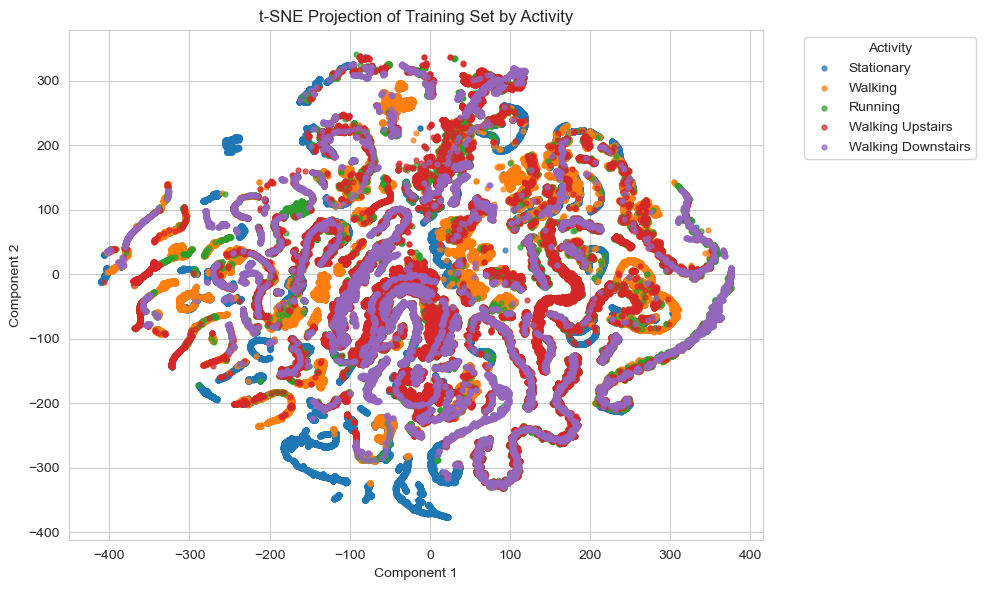

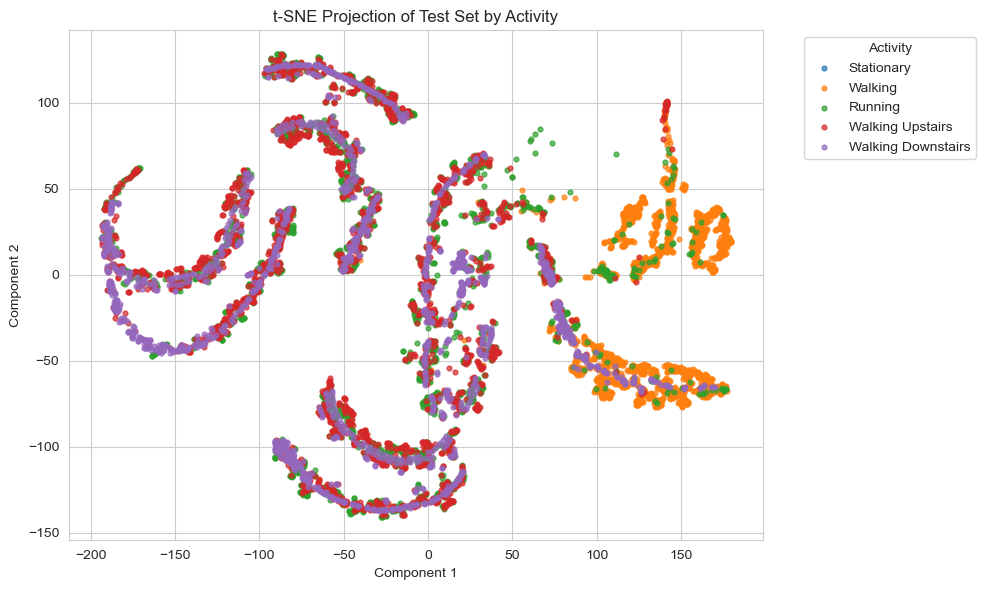

In [96]:
# TSNE
# Handle aNaN or infinite values before TSNE
X_train_tsne = X_train.replace([np.inf, -np.inf], np.nan).dropna()
X_test_tsne  = X_test.replace([np.inf, -np.inf], np.nan).dropna()

# Match labels to the cleaned rows
y_train_tsne = y_train.loc[X_train_tsne.index]
y_test_tsne  = y_test.loc[X_test_tsne.index]

# drop the paricipant column as it is not needed for TSNE
X_train_tsne = X_train_tsne.drop(columns=["participant"], errors="ignore")
X_test_tsne = X_test_tsne.drop(columns=["participant"], errors="ignore")    

# Map numeric labels to readable activity names
activity_map = {
    1.0: "Stationary",
    2.0: "Walking",
    3.0: "Running",
    4.0: "Walking Upstairs",
    5.0: "Walking Downstairs"
}

y_train_named = y_train_tsne.map(activity_map)
y_test_named  = y_test_tsne.map(activity_map)

# Compute t-SNE embeddings
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=10000)
X_train_tsne_embedded = tsne.fit_transform(X_train_tsne)
X_test_tsne_embedded  = tsne.fit_transform(X_test_tsne)

# Visualization — Training Set
palette = sns.color_palette("viridis", len(activity_map))
plt.figure(figsize=(10, 6))
for i, (label, name) in enumerate(activity_map.items()):
    mask = y_train_named == name
    plt.scatter(
                X_train_tsne_embedded[mask, 0],
                X_train_tsne_embedded[mask, 1],
                label=name,
                s=12,
                alpha=0.7
    )

plt.legend(title="Activity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("t-SNE Projection of Training Set by Activity")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

# Visualization — Test Set
plt.figure(figsize=(10, 6))
for i, (label, name) in enumerate(activity_map.items()):
    mask = y_test_named == name
    plt.scatter(
                X_test_tsne_embedded[mask, 0],
                X_test_tsne_embedded[mask, 1],
                label=name,
                s=12,
                alpha=0.7
    )

plt.legend(title="Activity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("t-SNE Projection of Test Set by Activity")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

The t-SNE plots look like a bowl of spaghetti, showing that the feature space is highly entangled with substantial overlap between activities. There is some slight distinction in a few regions that could correspond to Stationary data, but that separation might be due to a processing issue with how stationary samples were handled. Overall, the poor separability here aligns with the low classification performance, suggesting that either the feature extraction or data preprocessing needs refinement.

TO DO

KNN and Random Forest Classification.
Compute the confusion matrix and then compute the precision, recall and F1 score for each activity separately.

compare the performance of these two classifiers and comment on it.

Firstly, both models performed terribly on Stationary, so I need to check the data processing for that class. Overall, neither model performed very well, KNN reached only 22% accuracy with an average F1-score of 0.20 and precision of 0.26, while Random Forest achieved 48% accuracy, an average F1-score of 0.41, and precision of 0.52. However, Random Forest clearly performed better overall, roughly doubling the accuracy of KNN and showing stronger precision and recall across most activities, especially for Running and Walking Downstairs, which had F1-scores of 0.54 and 0.78, respectively.


KNN Accuracy: 0.2165

KNN Classification Report:
                    precision    recall  f1-score   support

           Running     0.2774    0.2578    0.2672      1691
        Stationary     0.0000    0.0000    0.0000         0
           Walking     0.2655    0.1680    0.2058      1809
Walking Downstairs     0.2230    0.3817    0.2815      1048
  Walking Upstairs     0.2782    0.2324    0.2533      1506

          accuracy                         0.2461      6054
         macro avg     0.2088    0.2080    0.2016      6054
      weighted avg     0.2646    0.2461    0.2479      6054



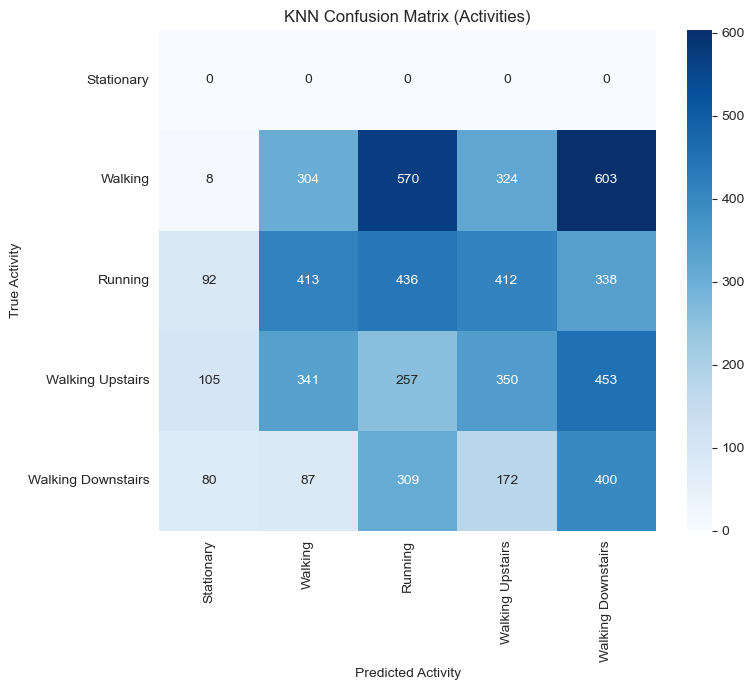

In [97]:
# Map numeric labels to readable activity names
activity_map = {
    1.0: "Stationary",
    2.0: "Walking",
    3.0: "Running",
    4.0: "Walking Upstairs",
    5.0: "Walking Downstairs"
}

# Clean and prepare data for KNN
X_train_knn = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_knn  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

#Drop participant column for KNN
X_train_knn = X_train_knn.drop(columns=["participant"], errors="ignore")
X_test_knn = X_test_knn.drop(columns=["participant"], errors="ignore")

# Align y to X (ensures same indices and lengths)
y_train_knn = y_train.loc[X_train_knn.index]
y_test_knn  = y_test.loc[X_test_knn.index]

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train_knn)

# Predict on test data
y_pred_knn = knn.predict(X_test_knn)

# Evaluate KNN performance
acc_knn = accuracy_score(y_test_knn, y_pred_knn)
print(f"\nKNN Accuracy: {acc_knn:.4f}\n")

# Convert numeric to readable labels
y_test_named = y_test_knn.map(activity_map)
y_pred_named = pd.Series(y_pred_knn).map(activity_map)

# Ensure consistent types (remove NaNs and cast to string)
mask = y_test_named.notna() & y_pred_named.notna()
y_test_named = y_test_named[mask].astype(str)
y_pred_named = y_pred_named[mask].astype(str)

print("KNN Classification Report:")
print(classification_report(y_test_named, y_pred_named, digits=4))

# Confusion Matrix
labels_ordered = list(activity_map.values())
conf_mat_knn = confusion_matrix(y_test_named, y_pred_named, labels=labels_ordered)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 7))
sns.heatmap(
    conf_mat_knn,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=labels_ordered,
    yticklabels=labels_ordered
)
plt.title("KNN Confusion Matrix (Activities)")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.tight_layout()
plt.show()


Random Forest Accuracy: 0.4797

Random Forest Classification Report:
                    precision    recall  f1-score   support

           Running     0.4897    0.6058    0.5416      2088
        Stationary     0.0000    0.0000    0.0000         0
           Walking     0.4598    0.2783    0.3467      1768
Walking Downstairs     0.9004    0.6865    0.7791      1225
  Walking Upstairs     0.3511    0.4154    0.3806      1743

          accuracy                         0.4868      6824
         macro avg     0.4402    0.3972    0.4096      6824
      weighted avg     0.5203    0.4868    0.4926      6824



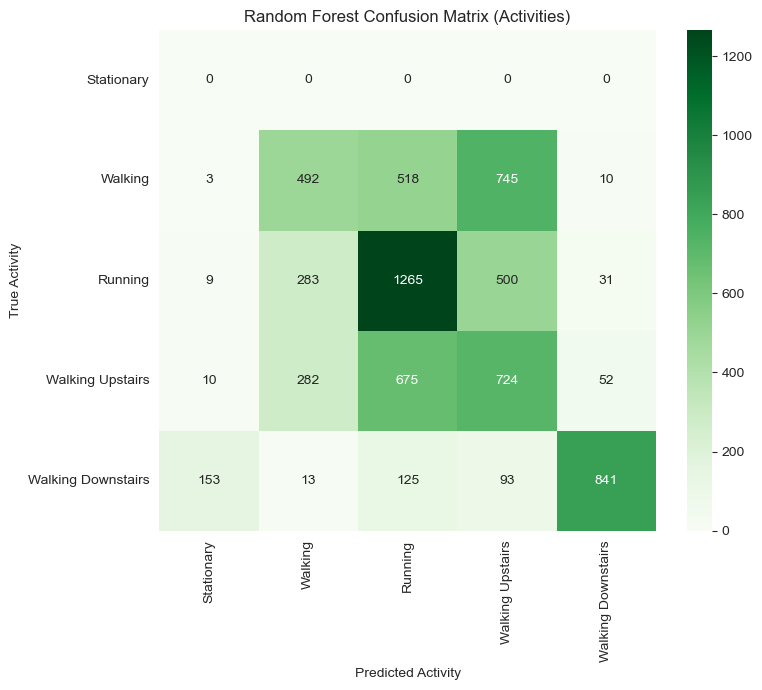

In [101]:
X_train_rf = X_train.drop(columns=["participant"], errors="ignore")
X_test_rf = X_test.drop(columns=["participant"], errors="ignore")

# Clean and prepare data for Random Forest
X_train_rf = X_train_rf.replace([np.inf, -np.inf], np.nan).fillna(X_train_rf.mean())
X_test_rf  = X_test_rf.replace([np.inf, -np.inf], np.nan).fillna(X_test_rf.mean())

#Drop participant column for Random Forest


# Align y to X (ensures same indices and lengths)
y_train_rf = y_train.loc[X_train_rf.index]
y_test_rf  = y_test.loc[X_test_rf.index]

# Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train_rf)

# Predict on test data
y_pred_rf = rf.predict(X_test_rf)

# Evaluate Random Forest performance
acc_rf = accuracy_score(y_test_rf, y_pred_rf)
print(f"\nRandom Forest Accuracy: {acc_rf:.4f}\n")

# Convert numeric to readable labels
y_test_named = y_test_rf.map(activity_map)
y_pred_named = pd.Series(y_pred_rf).map(activity_map)

# Ensure consistent types (remove NaNs and cast to string)
mask = y_test_named.notna() & y_pred_named.notna()
y_test_named = y_test_named[mask].astype(str)
y_pred_named = y_pred_named[mask].astype(str)

print("Random Forest Classification Report:")
print(classification_report(y_test_named, y_pred_named, digits=4))

# Confusion Matrix
labels_ordered = list(activity_map.values())
conf_mat_rf = confusion_matrix(y_test_named, y_pred_named, labels=labels_ordered)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 7))
sns.heatmap(
    conf_mat_rf,
    annot=True,
    fmt='d',
    cmap="Greens",
    xticklabels=labels_ordered,
    yticklabels=labels_ordered
)
plt.title("Random Forest Confusion Matrix (Activities)")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.tight_layout()
plt.show()

### Comparison of KNN to RF



TO DO

Time Domain vs Frequency Domain

Use just time domain and frequency domain features seperately and run the same classifier. Which domain ( frequency domain vs time domain ) is helping you the most in terms of building your activity recognition system ? Comment on it.

## KNN TD vs FD



In [ ]:
# Prepare data
df_time_train = pd.DataFrame(time_train)
df_time_test  = pd.DataFrame(time_test)
df_freq_train = pd.DataFrame(freq_train)
df_freq_test  = pd.DataFrame(freq_test)


X_train_time = df_time_train.drop(columns=["label"], errors="ignore").replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_time  = df_time_test.drop(columns=["label"], errors="ignore").replace([np.inf, -np.inf], np.nan).fillna(0)
y_train_time = df_time_train["label"]
y_test_time  = df_time_test["label"]

X_train_freq = df_freq_train.drop(columns=["label"], errors="ignore").replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_freq  = df_freq_test.drop(columns=["label"], errors="ignore").replace([np.inf, -np.inf], np.nan).fillna(0)
y_train_freq = df_freq_train["label"]
y_test_freq  = df_freq_test["label"]

### TD


KNN (Time Domain) Accuracy: 0.2165

KNN (Time Domain) Classification Report:
                    precision    recall  f1-score   support

           Running     0.2774    0.2578    0.2672      1691
        Stationary     0.0000    0.0000    0.0000         0
           Walking     0.2655    0.1680    0.2058      1809
Walking Downstairs     0.2230    0.3817    0.2815      1048
  Walking Upstairs     0.2782    0.2324    0.2533      1506

          accuracy                         0.2461      6054
         macro avg     0.2088    0.2080    0.2016      6054
      weighted avg     0.2646    0.2461    0.2479      6054



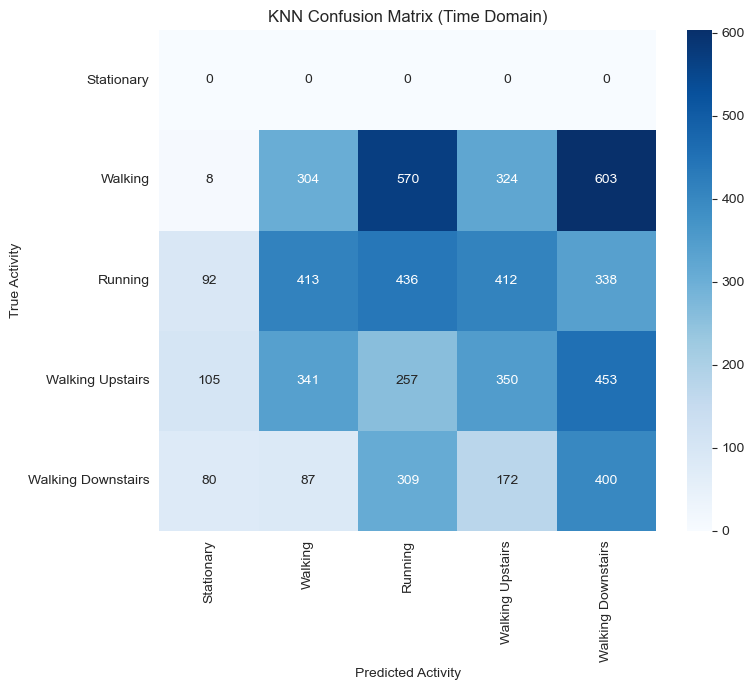

In [106]:
# KNN drop participant column for Time Domain
X_train_time = X_train_time.drop(columns=["participant"], errors="ignore")
X_test_time = X_test_time.drop(columns=["participant"], errors="ignore")

# Train model
knn_time = KNeighborsClassifier(n_neighbors=5)
knn_time.fit(X_train_time, y_train_time)
y_pred_knn_time = knn_time.predict(X_test_time)

# Evaluate
acc_knn_time = accuracy_score(y_test_time, y_pred_knn_time)
print(f"\nKNN (Time Domain) Accuracy: {acc_knn_time:.4f}\n")

y_test_named = y_test_time.map(activity_map)
y_pred_named = pd.Series(y_pred_knn_time).map(activity_map)
mask = y_test_named.notna() & y_pred_named.notna()
y_test_named = y_test_named[mask].astype(str)
y_pred_named = y_pred_named[mask].astype(str)

print("KNN (Time Domain) Classification Report:")
print(classification_report(y_test_named, y_pred_named, digits=4))

# Confusion matrix
labels_ordered = list(activity_map.values())
conf_mat_knn_time = confusion_matrix(y_test_named, y_pred_named, labels=labels_ordered)

plt.figure(figsize=(8, 7))
sns.heatmap(conf_mat_knn_time, annot=True, fmt='d', cmap="Blues",
            xticklabels=labels_ordered, yticklabels=labels_ordered)
plt.title("KNN Confusion Matrix (Time Domain)")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.tight_layout()
plt.show()

### FD


KNN (Frequency Domain) Accuracy: 0.2741

KNN (Frequency Domain) Classification Report:
                    precision    recall  f1-score   support

           Running     0.3198    0.2818    0.2996      2065
        Stationary     0.0000    0.0000    0.0000         0
           Walking     0.2453    0.4010    0.3044      1601
Walking Downstairs     0.8633    0.3509    0.4990      1368
  Walking Upstairs     0.2716    0.1799    0.2165      1784

          accuracy                         0.2970      6818
         macro avg     0.3400    0.2427    0.2639      6818
      weighted avg     0.3987    0.2970    0.3190      6818



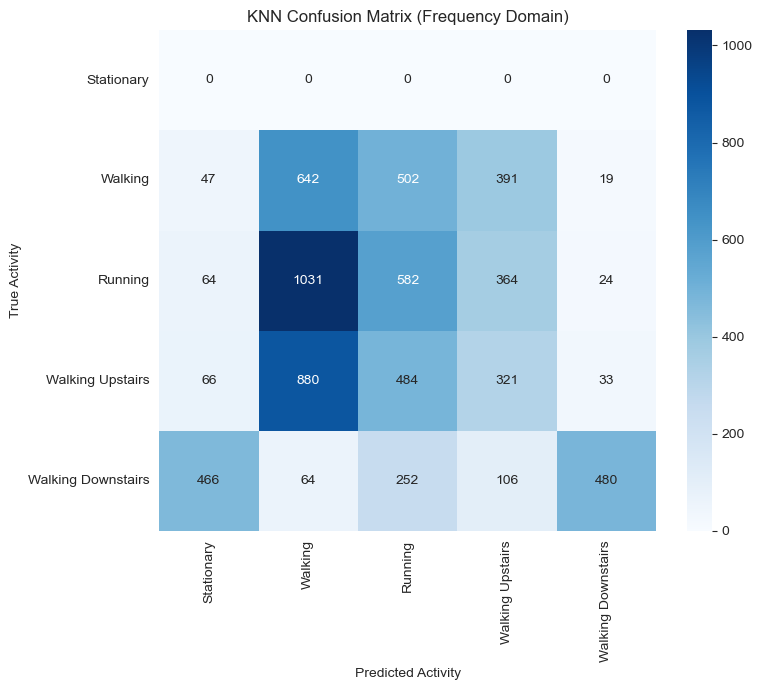

In [107]:
# Drop time participant column for Frequency Domain
X_train_freq = X_train_freq.drop(columns=["participant"], errors="ignore")
X_test_freq = X_test_freq.drop(columns=["participant"], errors="ignore")

knn_freq = KNeighborsClassifier(n_neighbors=5)
knn_freq.fit(X_train_freq, y_train_freq)
y_pred_knn_freq = knn_freq.predict(X_test_freq)

acc_knn_freq = accuracy_score(y_test_freq, y_pred_knn_freq)
print(f"\nKNN (Frequency Domain) Accuracy: {acc_knn_freq:.4f}\n")

y_test_named = y_test_freq.map(activity_map)
y_pred_named = pd.Series(y_pred_knn_freq).map(activity_map)
mask = y_test_named.notna() & y_pred_named.notna()
y_test_named = y_test_named[mask].astype(str)
y_pred_named = y_pred_named[mask].astype(str)

print("KNN (Frequency Domain) Classification Report:")
print(classification_report(y_test_named, y_pred_named, digits=4))

labels_ordered = list(activity_map.values())
conf_mat_knn_freq = confusion_matrix(y_test_named, y_pred_named, labels=labels_ordered)

plt.figure(figsize=(8, 7))
sns.heatmap(conf_mat_knn_freq, annot=True, fmt='d', cmap="Blues",
            xticklabels=labels_ordered, yticklabels=labels_ordered)
plt.title("KNN Confusion Matrix (Frequency Domain)")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.tight_layout()
plt.show()

## Random Forest TD vs FD

### TD


Random Forest (Time Domain) Accuracy: 0.4782

Random Forest (Time Domain) Classification Report:
                    precision    recall  f1-score   support

           Running     0.4867    0.5862    0.5318      2088
        Stationary     0.0000    0.0000    0.0000         0
           Walking     0.4239    0.2712    0.3308      1766
Walking Downstairs     0.9049    0.7248    0.8049      1312
  Walking Upstairs     0.3245    0.3781    0.3493      1711

          accuracy                         0.4800      6877
         macro avg     0.4280    0.3921    0.4034      6877
      weighted avg     0.5100    0.4800    0.4869      6877



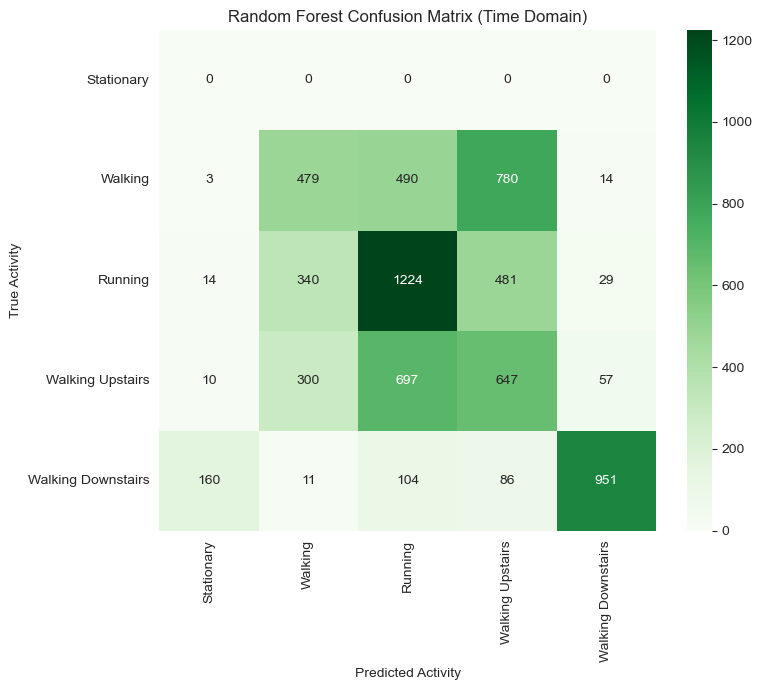

In [108]:
rf_time = RandomForestClassifier(n_estimators=100, random_state=42)
rf_time.fit(X_train_time, y_train_time)
y_pred_rf_time = rf_time.predict(X_test_time)

acc_rf_time = accuracy_score(y_test_time, y_pred_rf_time)
print(f"\nRandom Forest (Time Domain) Accuracy: {acc_rf_time:.4f}\n")

y_test_named = y_test_time.map(activity_map)
y_pred_named = pd.Series(y_pred_rf_time).map(activity_map)
mask = y_test_named.notna() & y_pred_named.notna()
y_test_named = y_test_named[mask].astype(str)
y_pred_named = y_pred_named[mask].astype(str)

print("Random Forest (Time Domain) Classification Report:")
print(classification_report(y_test_named, y_pred_named, digits=4))

labels_ordered = list(activity_map.values())
conf_mat_rf_time = confusion_matrix(y_test_named, y_pred_named, labels=labels_ordered)

plt.figure(figsize=(8, 7))
sns.heatmap(conf_mat_rf_time, annot=True, fmt='d', cmap="Greens",
            xticklabels=labels_ordered, yticklabels=labels_ordered)
plt.title("Random Forest Confusion Matrix (Time Domain)")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.tight_layout()
plt.show()

### FD




Random Forest (Frequency Domain) Accuracy: 0.3228

Random Forest (Frequency Domain) Classification Report:
                    precision    recall  f1-score   support

           Running     0.3178    0.3441    0.3304      2046
        Stationary     0.0000    0.0000    0.0000         0
           Walking     0.2247    0.2779    0.2485      1637
Walking Downstairs     0.9366    0.4014    0.5620      1288
  Walking Upstairs     0.3143    0.2950    0.3043      1773

          accuracy                         0.3261      6744
         macro avg     0.3587    0.2637    0.2890      6744
      weighted avg     0.4125    0.3261    0.3479      6744



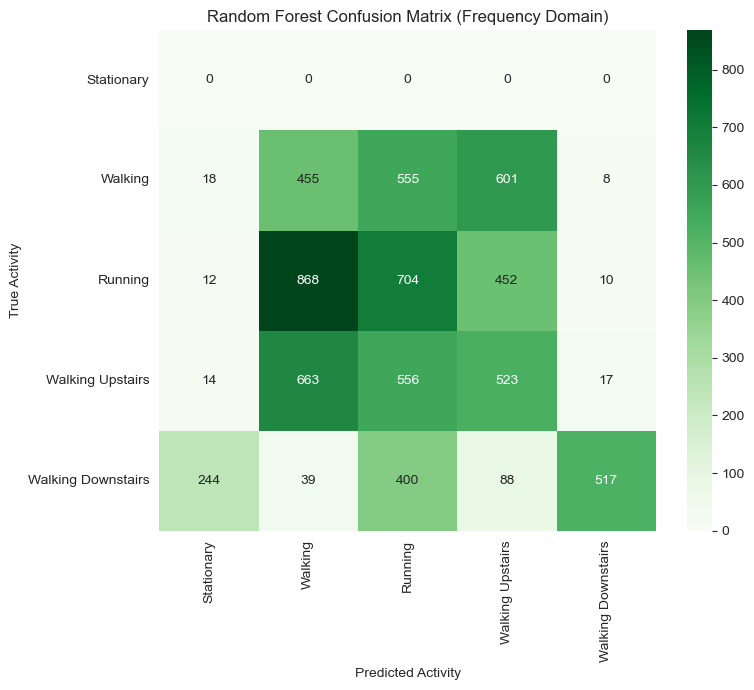

In [109]:
rf_freq = RandomForestClassifier(n_estimators=100, random_state=42)
rf_freq.fit(X_train_freq, y_train_freq)
y_pred_rf_freq = rf_freq.predict(X_test_freq)

acc_rf_freq = accuracy_score(y_test_freq, y_pred_rf_freq)
print(f"\nRandom Forest (Frequency Domain) Accuracy: {acc_rf_freq:.4f}\n")

y_test_named = y_test_freq.map(activity_map)
y_pred_named = pd.Series(y_pred_rf_freq).map(activity_map)
mask = y_test_named.notna() & y_pred_named.notna()
y_test_named = y_test_named[mask].astype(str)
y_pred_named = y_pred_named[mask].astype(str)

print("Random Forest (Frequency Domain) Classification Report:")
print(classification_report(y_test_named, y_pred_named, digits=4))

labels_ordered = list(activity_map.values())
conf_mat_rf_freq = confusion_matrix(y_test_named, y_pred_named, labels=labels_ordered)

plt.figure(figsize=(8, 7))
sns.heatmap(conf_mat_rf_freq, annot=True, fmt='d', cmap="Greens",
            xticklabels=labels_ordered, yticklabels=labels_ordered)
plt.title("Random Forest Confusion Matrix (Frequency Domain)")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.tight_layout()
plt.show()

# Comparing Time and Frequency Domains

In the KNN, performance improved when using frequency domain features, accuracy rose from 0.22 to 0.27, and the weighted F1 score increased from 0.25 to 0.32. KNN still struggled overall due to overlapping feature distributions and limited separation between activity classes. The frequency domain likely performed better because it captured more separable differences between activities, while the time domain features mainly reflected raw signal amplitude and dispersion patterns.

In the Random Forest, the time domain features outperformed the frequency-domain ones by a large margin, achieving 48% accuracy vs. 32%, and a weighted F1-score of 0.49 vs. 0.35. Although this is still not ideal, it indicates that Random Forests leveraged statistical characteristics from the overall signal such as variance, skewness, and energy more effectively than frequency based transformations.

So we can see that while frequency features slightly helped KNN, Random Forests benefited more from time domain data, possibly because those features better represent the signal’s overall motion and variability structure.

TO DO

Cross validation- you will implement Leave One Subject Out Cross Validation . 

For this task, you are free to select any classifier you like.



Gradient Boosting Accuracy: 0.4563

Gradient Boosting Classification Report:
                    precision    recall  f1-score   support

           Running     0.4230    0.5219    0.4673      2121
        Stationary     0.0000    0.0000    0.0000         0
           Walking     0.1806    0.1077    0.1349      1830
Walking Downstairs     0.9330    0.6564    0.7707      1336
  Walking Upstairs     0.3315    0.4107    0.3668      1870

          accuracy                         0.4120      7157
         macro avg     0.3736    0.3393    0.3479      7157
      weighted avg     0.4323    0.4120    0.4127      7157



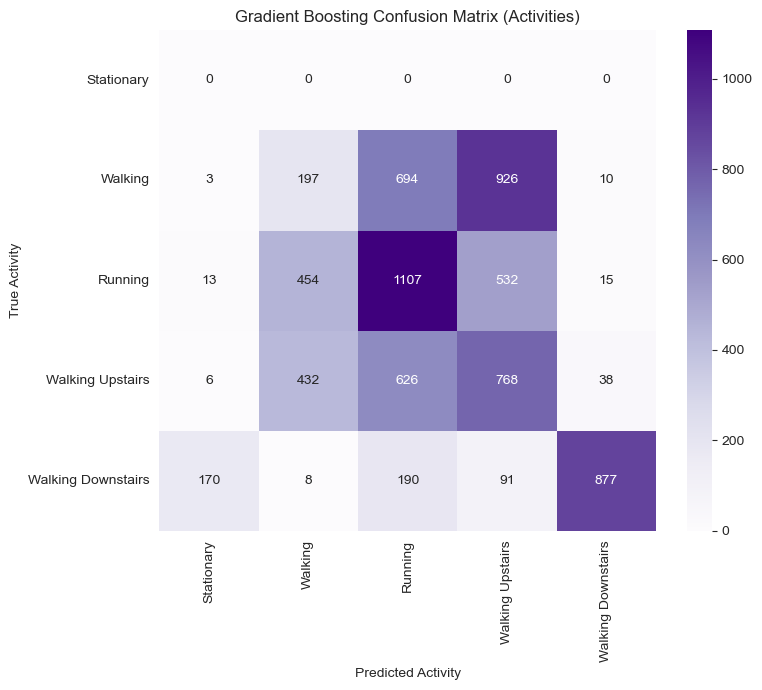

In [113]:
# Clean participant/user columns and drop missing rows with labels aligned 
X_train_gb = X_train.drop(columns=["user", "participant"], errors="ignore")
X_test_gb  = X_test.drop(columns=["user", "participant"], errors="ignore")

# Drop rows with NaNs while keeping y aligned
train_mask = ~X_train_gb.isna().any(axis=1)
test_mask  = ~X_test_gb.isna().any(axis=1)

X_train_gb = X_train_gb[train_mask]
y_train_gb = y_train[train_mask]

X_test_gb  = X_test_gb[test_mask]
y_test_gb  = y_test[test_mask]

# Define Ray-parallelized Gradient Boosting training
@ray.remote
def train_and_eval(X_train, X_test, y_train, y_test):
    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc, y_test.tolist(), y_pred.tolist()

# Run in parallel (single task but Ray handles it)
future = train_and_eval.remote(X_train_gb, X_test_gb, y_train_gb, y_test_gb)
acc_gb, y_true_list, y_pred_list = ray.get(future)

# Prepare named labels for metrics
y_test_named = pd.Series(y_true_list).map(activity_map)
y_pred_named = pd.Series(y_pred_list).map(activity_map)

mask = y_test_named.notna() & y_pred_named.notna()
y_test_named = y_test_named[mask].astype(str)
y_pred_named = y_pred_named[mask].astype(str)

# Evaluation metrics
print(f"\nGradient Boosting Accuracy: {acc_gb:.4f}\n")
print("Gradient Boosting Classification Report:")
print(classification_report(y_test_named, y_pred_named, digits=4))

# Confusion Matrix
labels_ordered = list(activity_map.values())
conf_mat_gb = confusion_matrix(y_test_named, y_pred_named, labels=labels_ordered)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 7))
sns.heatmap(
    conf_mat_gb,
    annot=True,
    fmt='d',
    cmap="Purples",
    xticklabels=labels_ordered,
    yticklabels=labels_ordered
)
plt.title("Gradient Boosting Confusion Matrix (Activities)")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.tight_layout()
plt.show()

BONUS POINTS

Try building a basic CNN model and use either the raw time series data or the extracted feature set as input and try to classify the different activities
